# Analyze data exported to excel from the LC/MS
This notebook will extract and plot m/z spectrum data exported from Advion DataExpress, and highlight some [common background peaks](https://ccc.bc.edu/content/dam/bc1/top-tier/research/VPR/research-facilities/fisher-chemical-poster.pdf). To export data, hit "Export Peaks to Excel" in DataExpress, and select "Spectrum".

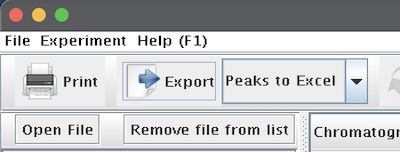

This will export *all* the peaks from every file you have open. This notebook can handle single or multiple spectra. 

## How to use this notebook:
1. Process your LCMS data with Advion DataExpress and export as described above.
2. Upload your file to the colab instance
- Click the folder icon on the left toolbar then drag your input file into the folder area
5. Replace the example path with your file's path
- Right click on your file and click "copy path"
- make sure it's enclosed in the quotes when you paste it
6. Run the function to create your plots
- click the round circle with arrow next to the cell or hit shift+enter when your cursor is anywhere in the cell
7. Download the saved files locally
- All files will be deleted shortly after you close the notebook instance
- If you can't see the new files, click the refresh folder icon at the top of the folder area


In [3]:
import pandas as pd
import sys
import importlib
sys.path.append('./smdc_process_data')
from process_data import analyze_lcms as al

## Plot a single spectra

In [ ]:
%%time
!git clone https://github.com/Small-Molecule-Discovery-Center/smdc_process_data.git
import sys
sys.path.append('/content/smdc_process_data')
from process_data import tethering_analysis as ta

##################################
# # PASTE YOUR FILE NAME BELOW # #
##################################
spectrum_file = "/content/example_LCMS_spectrum_data.xlsx"
##################################

data_df=al.read_lcms_results(infile=spectrum_file, kind="spectrum")



,sample_id,wavelength_peak_maximum_nm,maximum_absorption_mau,wavelength_peak_centroid_nm,relative_wavelength_peak_centroid_nm,peak_area,pct_peak_area,peak_resolution,signal_to_noise_ratio,label,mass_peak_maximum_mz,maximum_intensity_cs,mass_peak_centroid_mz,relative_mass_peak_centroid_mz
0,04036CB-INO2-B10_1_UV,210,1000.0,207.9,NaN,750.0,7.3,10.0,NaN,NaN,NaN,NaN,NaN,NaN
1,04036CB-INO2-B10_1_UV,228,1200.0,225.9,NaN,9500.0,92.1,33.0,NaN,NaN,NaN,NaN,NaN,NaN
2,04036CB-INO2-B10_1_UV,326,100.0,327.3,NaN,61.0,0.6,19.3,NaN,NaN,NaN,NaN,NaN,NaN
3,04036CB-INO2-B10_1,NaN,NaN,NaN,NaN,74000.0,0.0,0.1,NaN,NaN,101.1,690000.0,101.1,NaN
4,04036CB-INO2-B10_1,NaN,NaN,NaN,NaN,1800000.0,0.2,0.3,NaN,NaN,102.2,5400000.0,102.1,NaN


In [ ]:
info_df=pd.DataFrame({
    
})

## Get the info for the compounds we ran

In [41]:
library="Chembridge_Gallo"
plate_barcode="04036CB-IN03"
info_df=pd.read_csv(f"./00_library_data/{library}_{plate_barcode}_selected_wells.csv")
info_df

# library="Chembridge_Gallo"
# info_df=pd.read_csv(f"./00_library_data/20251022_{library}_selected_wells_with_mw.csv")
# info_df.head(5)

,Well,Vendor_Alias,SMDC_ID,Common_Name,Lot_Num,Conc_uM,Conc_nM,SMILES,Row,Col,Plate,MolWt
0,B10,5423061,27348.0,NaN,1.0,10000.0,NaN,[O-][N+](=O)c1ccccc1CN2CCCC2,B,10,04036CB-IN03,206.245
1,C17,5412440,27122.0,NaN,1.0,10000.0,NaN,CCN1CCC(CC1)NC2C3CC4CC(CC2C4)C3,C,17,04036CB-IN03,262.441
2,K21,5406312,27164.0,NaN,1.0,10000.0,NaN,CC(Cc1ccccc1)NC(=O)c2ccc(N)cc2,K,21,04036CB-IN03,254.333
3,O07,5410536,27177.0,NaN,1.0,10000.0,NaN,[O-][N+](=O)c1ccc(cc1)N2CCN(Cc3c(F)cccc3F)CC2,O,7,04036CB-IN03,333.338
4,O17,5412413,27182.0,NaN,1.0,10000.0,NaN,COc1cccc(CCNC2C3CC4CC(CC2C4)C3)c1,O,17,04036CB-IN03,285.431
5,P12,5421803,27419.0,NaN,1.0,10000.0,NaN,COc1cc(CN(CCCN(C)C)CCCN(C)C)ccc1OCc2ccccc2,P,12,04036CB-IN03,413.606


In [42]:
# only for test plate
info_df.Plate=info_df.Plate.str.replace("-IN03","-INO2")

In [45]:
info_df['sample_id']=info_df['Plate']+"-"+info_df['Well']+"_"+info_df['Lot_Num'].astype(int).astype(str)
info_df.head(5)

# info_df['sample_id']=info_df['SMDC_ID'].astype(int).astype(str)+"_"+info_df['Well']
# info_df['smdc_id']=info_df['SMDC_ID'].astype(int)
# info_df.head(5)

,Well,Vendor_Alias,SMDC_ID,Common_Name,Lot_Num,Conc_uM,Conc_nM,SMILES,Row,Col,Plate,MolWt,sample_id
0,B10,5423061,27348.0,NaN,1.0,10000.0,NaN,[O-][N+](=O)c1ccccc1CN2CCCC2,B,10,04036CB-INO2,206.245,04036CB-INO2-B10_1
1,C17,5412440,27122.0,NaN,1.0,10000.0,NaN,CCN1CCC(CC1)NC2C3CC4CC(CC2C4)C3,C,17,04036CB-INO2,262.441,04036CB-INO2-C17_1
2,K21,5406312,27164.0,NaN,1.0,10000.0,NaN,CC(Cc1ccccc1)NC(=O)c2ccc(N)cc2,K,21,04036CB-INO2,254.333,04036CB-INO2-K21_1
3,O07,5410536,27177.0,NaN,1.0,10000.0,NaN,[O-][N+](=O)c1ccc(cc1)N2CCN(Cc3c(F)cccc3F)CC2,O,7,04036CB-INO2,333.338,04036CB-INO2-O07_1
4,O17,5412413,27182.0,NaN,1.0,10000.0,NaN,COc1cccc(CCNC2C3CC4CC(CC2C4)C3)c1,O,17,04036CB-INO2,285.431,04036CB-INO2-O17_1


In [46]:
scan_range=5

In [ ]:
importlib.reload(al)



array(['04036CB-INO2-B10_1_UV', '04036CB-INO2-B10_1',
       '04036CB-INO2-C17_1_UV', '04036CB-INO2-C17_1',
       '04036CB-INO2-K21_1_UV', '04036CB-INO2-K21_1',
       '04036CB-INO2-O07_1_UV', '04036CB-INO2-O07_1',
       '04036CB-INO2-O17_1_UV', '04036CB-INO2-O17_1',
       '04036CB-INO2-P12_1_UV', '04036CB-INO2-P12_1'], dtype=object)

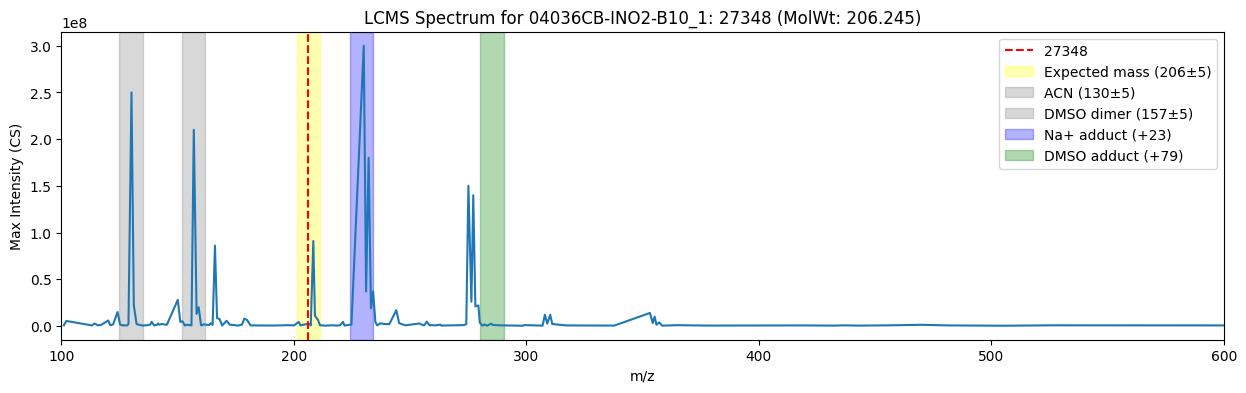

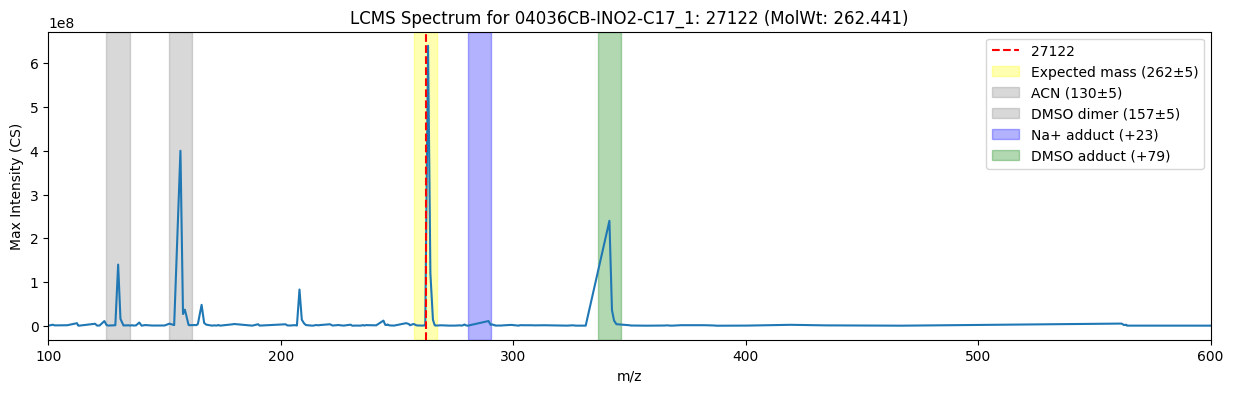

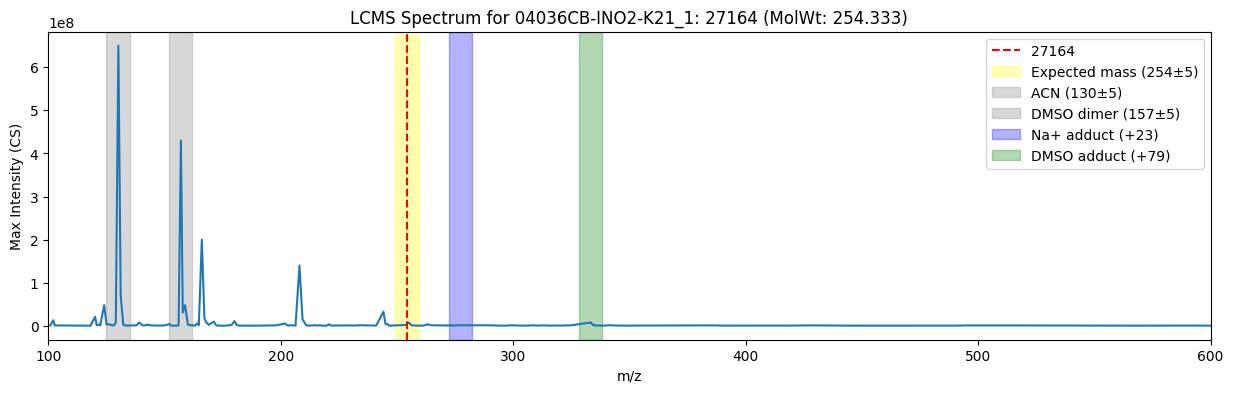

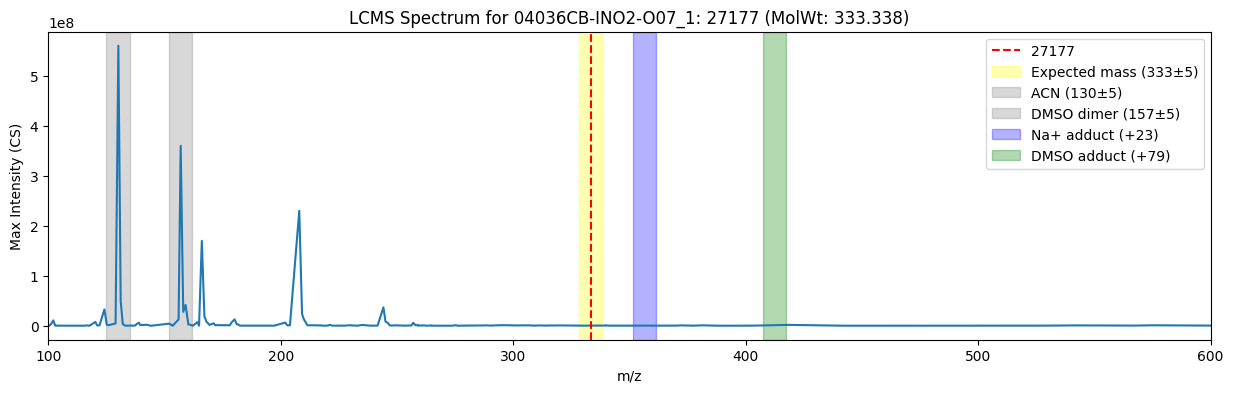

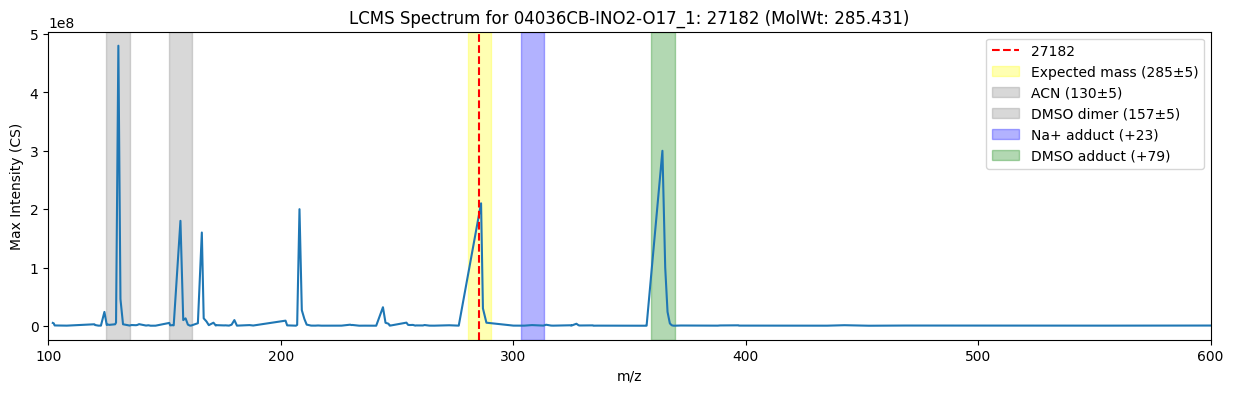

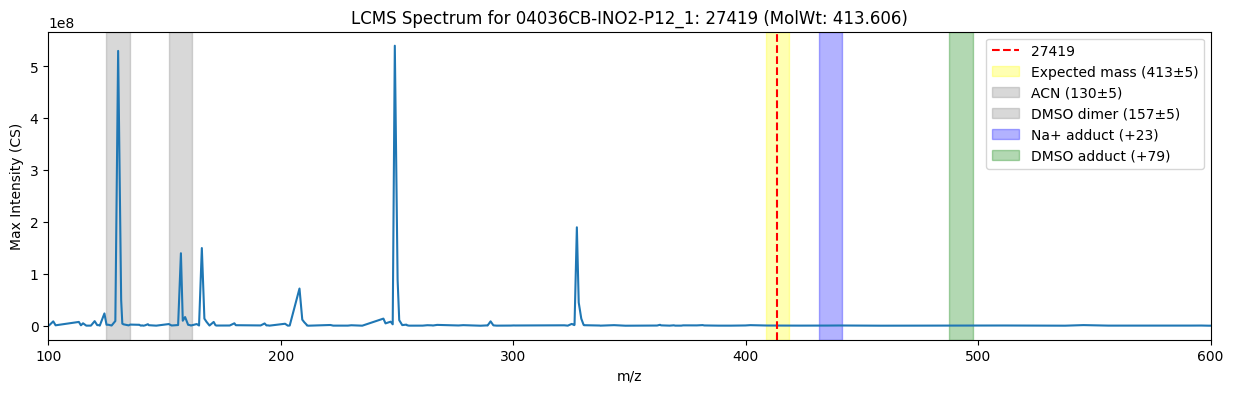

In [52]:
importlib.reload(al)
# plot each spectra for inspection
for sample_id in data_df.sample_id.unique():
    if "UV" in sample_id:
        continue
    al.plot_lcms_spectrum(sample_id, info_df, data_df, scan_range,)# save_dir='./04_analysis_output/mz_spectra')

In [ ]:
data_df[data_df.mass_peak_maximum_mz.between(250,260)]

## UV analysis
- look at which wavelengths show absorption
- look at TIC (time vs signal) and TUVC (time vs UV)

In [ ]:
sample_id

In [ ]:
df=al.read_lcms_results(sample_id+"_UV", '20251028', "spectrum")
al.plot_uv_absorption_nm(data_df=df, sample_id=sample_id+"_UV")

In [ ]:
# importlib.reload(al)
for sample_id in info_df['sample_id'].tolist():
    df=al.read_lcms_results(sample_id+"_UV", '20251028', "spectrum")
    al.plot_uv_absorption_nm(data_df=df, sample_id=sample_id+"_UV", save_dir="./04_lcms_plots")

## Chromatogram

In [ ]:
##Lollipop plots
# importlib.reload(al)

for sample_id in info_df['sample_id'].tolist():
    df=al.read_lcms_results(sample_id+"_UV", '20251117', "chromatogram")
    al.plot_uv_vs_time(data_df=df, sample_id=sample_id+"_UV", save_dir="./04_lcms_plots/UV_lolli")

## Histogram of Results

In [14]:
df1022 = pd.read_csv("./00_library_data/20251022_Chembridge_Gallo_selected_wells_with_mw.csv")
df1022['sample_id']=df1022['smdc_id'].astype(int).astype(str)+"_"+df1022['well']

df1031 = pd.read_csv("./00_library_data/20251031_Chembridge_Gallo_selected_wells_with_mw.csv")
df1031['sample_id']=df1031['SMDC_ID'].astype(int).astype(str)+"_"+df1031['Well']

df1106 = pd.read_csv("./00_library_data/20251106_Chembridge_Gallo_selected_wells_with_mw.csv")
df1106['sample_id']=df1106['SMDC_ID'].astype(int).astype(str)+"_"+df1106['Well']

df1117 = pd.read_csv("./00_library_data/20251117_Chembridge_Gallo_selected_wells_with_mw.csv")
df1117['sample_id']=df1117['SMDC_ID'].astype(int).astype(str)+"_"+df1117['Well']

max_peaks = []

for sample_id in df1022['sample_id'].tolist():
    df=al.read_lcms_results(sample_id+"_UV", '20251028', "chromatogram")
    max_peak = df['pct_peak_area'].max()
    max_peaks.append({"max_peak_area_pct": max_peak})

for sample_id in df1031['sample_id'].tolist():
    df=al.read_lcms_results(sample_id+"_UV", '20251031', "chromatogram")
    max_peak = df['pct_peak_area'].max()
    max_peaks.append({"max_peak_area_pct": max_peak})

for sample_id in df1106['sample_id'].tolist():
    df=al.read_lcms_results(sample_id+"_UV", '20251106', "chromatogram")
    max_peak = df['pct_peak_area'].max()
    max_peaks.append({"max_peak_area_pct": max_peak})

for sample_id in df1117['sample_id'].tolist():
    df=al.read_lcms_results(sample_id+"_UV", '20251117', "chromatogram")
    max_peak = df['pct_peak_area'].max()
    max_peaks.append({"max_peak_area_pct": max_peak})

max_peaks_df = pd.DataFrame(max_peaks)
max_peaks_df.shape


(280, 1)

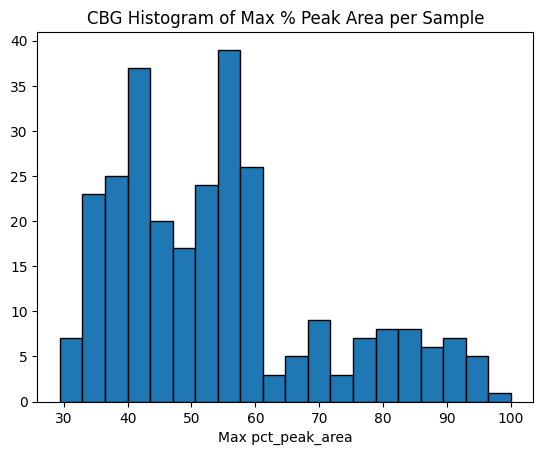

In [15]:
#plot the histogram
import matplotlib.pyplot as plt

plt.hist(max_peaks_df, bins=20, edgecolor="black")
plt.xlabel("Max pct_peak_area")
plt.title("CBG Histogram of Max % Peak Area per Sample")
plt.show()

## ID Low UV Results

In [5]:
high_peaks = []

for sample_id in info_df['sample_id'].tolist():
    df = al.read_lcms_results(sample_id+"_UV", "20251117", kind="chromatogram")
    df.columns = df.columns.str.strip()

    hits = df[df["pct_peak_area"].astype(float) > 85].copy()

    hits["sample_id"] = sample_id
    high_peaks.append(hits)

# Safe concatenation
if high_peaks:
    high_peaks_df = pd.concat(high_peaks, ignore_index=True)
else:
    high_peaks_df = pd.DataFrame()

high_peaks_df
# low_peaks_df.to_csv("./03_lcms_results/low_uv_peaks_20251028.csv", index=False)

,time_peak_maximum_msminutes,maximum_absorption_mau,time_peak_centroid_msminutes,peak_area,pct_peak_area,peak_resolution,signal_to_noise_ratio,label,library_compound,wavelength,sample_id
0,0.9,1500.0,0.90,21000.0,94.3,11.3,NaN,NaN,NaN,320,41205_M03
1,0.92,1500.0,0.91,23000.0,95.2,12.5,NaN,NaN,NaN,320,42114_C21
2,3.12,1200.0,3.14,18000.0,89.5,12.7,NaN,NaN,NaN,320,43213_B09
3,0.92,990.0,0.92,13000.0,92.8,11.2,NaN,NaN,NaN,320,44601_H12


In [6]:
low_peaks = info_df[~info_df['sample_id'].isin(high_peaks_df['sample_id'])]
low_peaks

,Well,Vendor_Alias,SMDC_ID,Common_Name,Lot_Num,Conc_uM,Conc_nM,SMILES,Row,Col,Plate,mol_weight,sample_id,smdc_id
0,G03,5175503,39900.0,NaN,1.0,10000.0,NaN,Clc1ccc(cc1)S(=O)(=O)n2c(COc3ccc(Cl)cc3Cl)nc4c...,G,3,04076CB-MA01,467.761,39900_G03,39900
1,H14,5210693,40144.0,NaN,1.0,10000.0,NaN,OC(=O)c1ccc(cc1)S(=O)(=O)c2ccc(cc2)S(=O)(=O)c3...,H,14,04076CB-MA01,490.467,40144_H14,40144
2,N18,5210810,40176.0,NaN,1.0,10000.0,NaN,OC(=O)c1ccc(NS(=O)(=O)c2cccc(c2)C(=O)Nc3ccccc3...,N,18,04076CB-MA01,396.424,40176_N18,40176
3,O13,5185333,39945.0,NaN,1.0,10000.0,NaN,CCOC(=O)c1cnc2cc(Cl)c(C)cc2c1O,O,13,04076CB-MA01,265.696,39945_O13,39945
4,O21,5186694,39949.0,NaN,1.0,10000.0,NaN,OC(=O)c1cc(cc(c1)N2C(=O)c3ccccc3C2=O)N4C(=O)c5...,O,21,04076CB-MA01,412.357,39949_O21,39949
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,B18,5380345,44892.0,NaN,1.0,10000.0,NaN,CCOC(=O)C1=C(C)N(CCOC)C(=O)/C/1=C\c2ccc(C)cc2,B,18,04091CB-MA01,329.396,44892_B18,44892
76,F13,5358874,44831.0,NaN,1.0,10000.0,NaN,Cc1cc(c2oc3ccccc3n2)c4ccccc4n1,F,13,04091CB-MA01,260.296,44831_F13,44831
77,G07,5350043,44679.0,NaN,1.0,10000.0,NaN,CN1N=CC2=C(SC3=C(S2)C=NN(C)C3=O)C1=O,G,7,04091CB-MA01,280.334,44679_G07,44679
78,H13,5359572,44841.0,NaN,1.0,10000.0,NaN,Brc1ccccc1OCCCCCCn2ccnc2,H,13,04091CB-MA01,323.234,44841_H13,44841


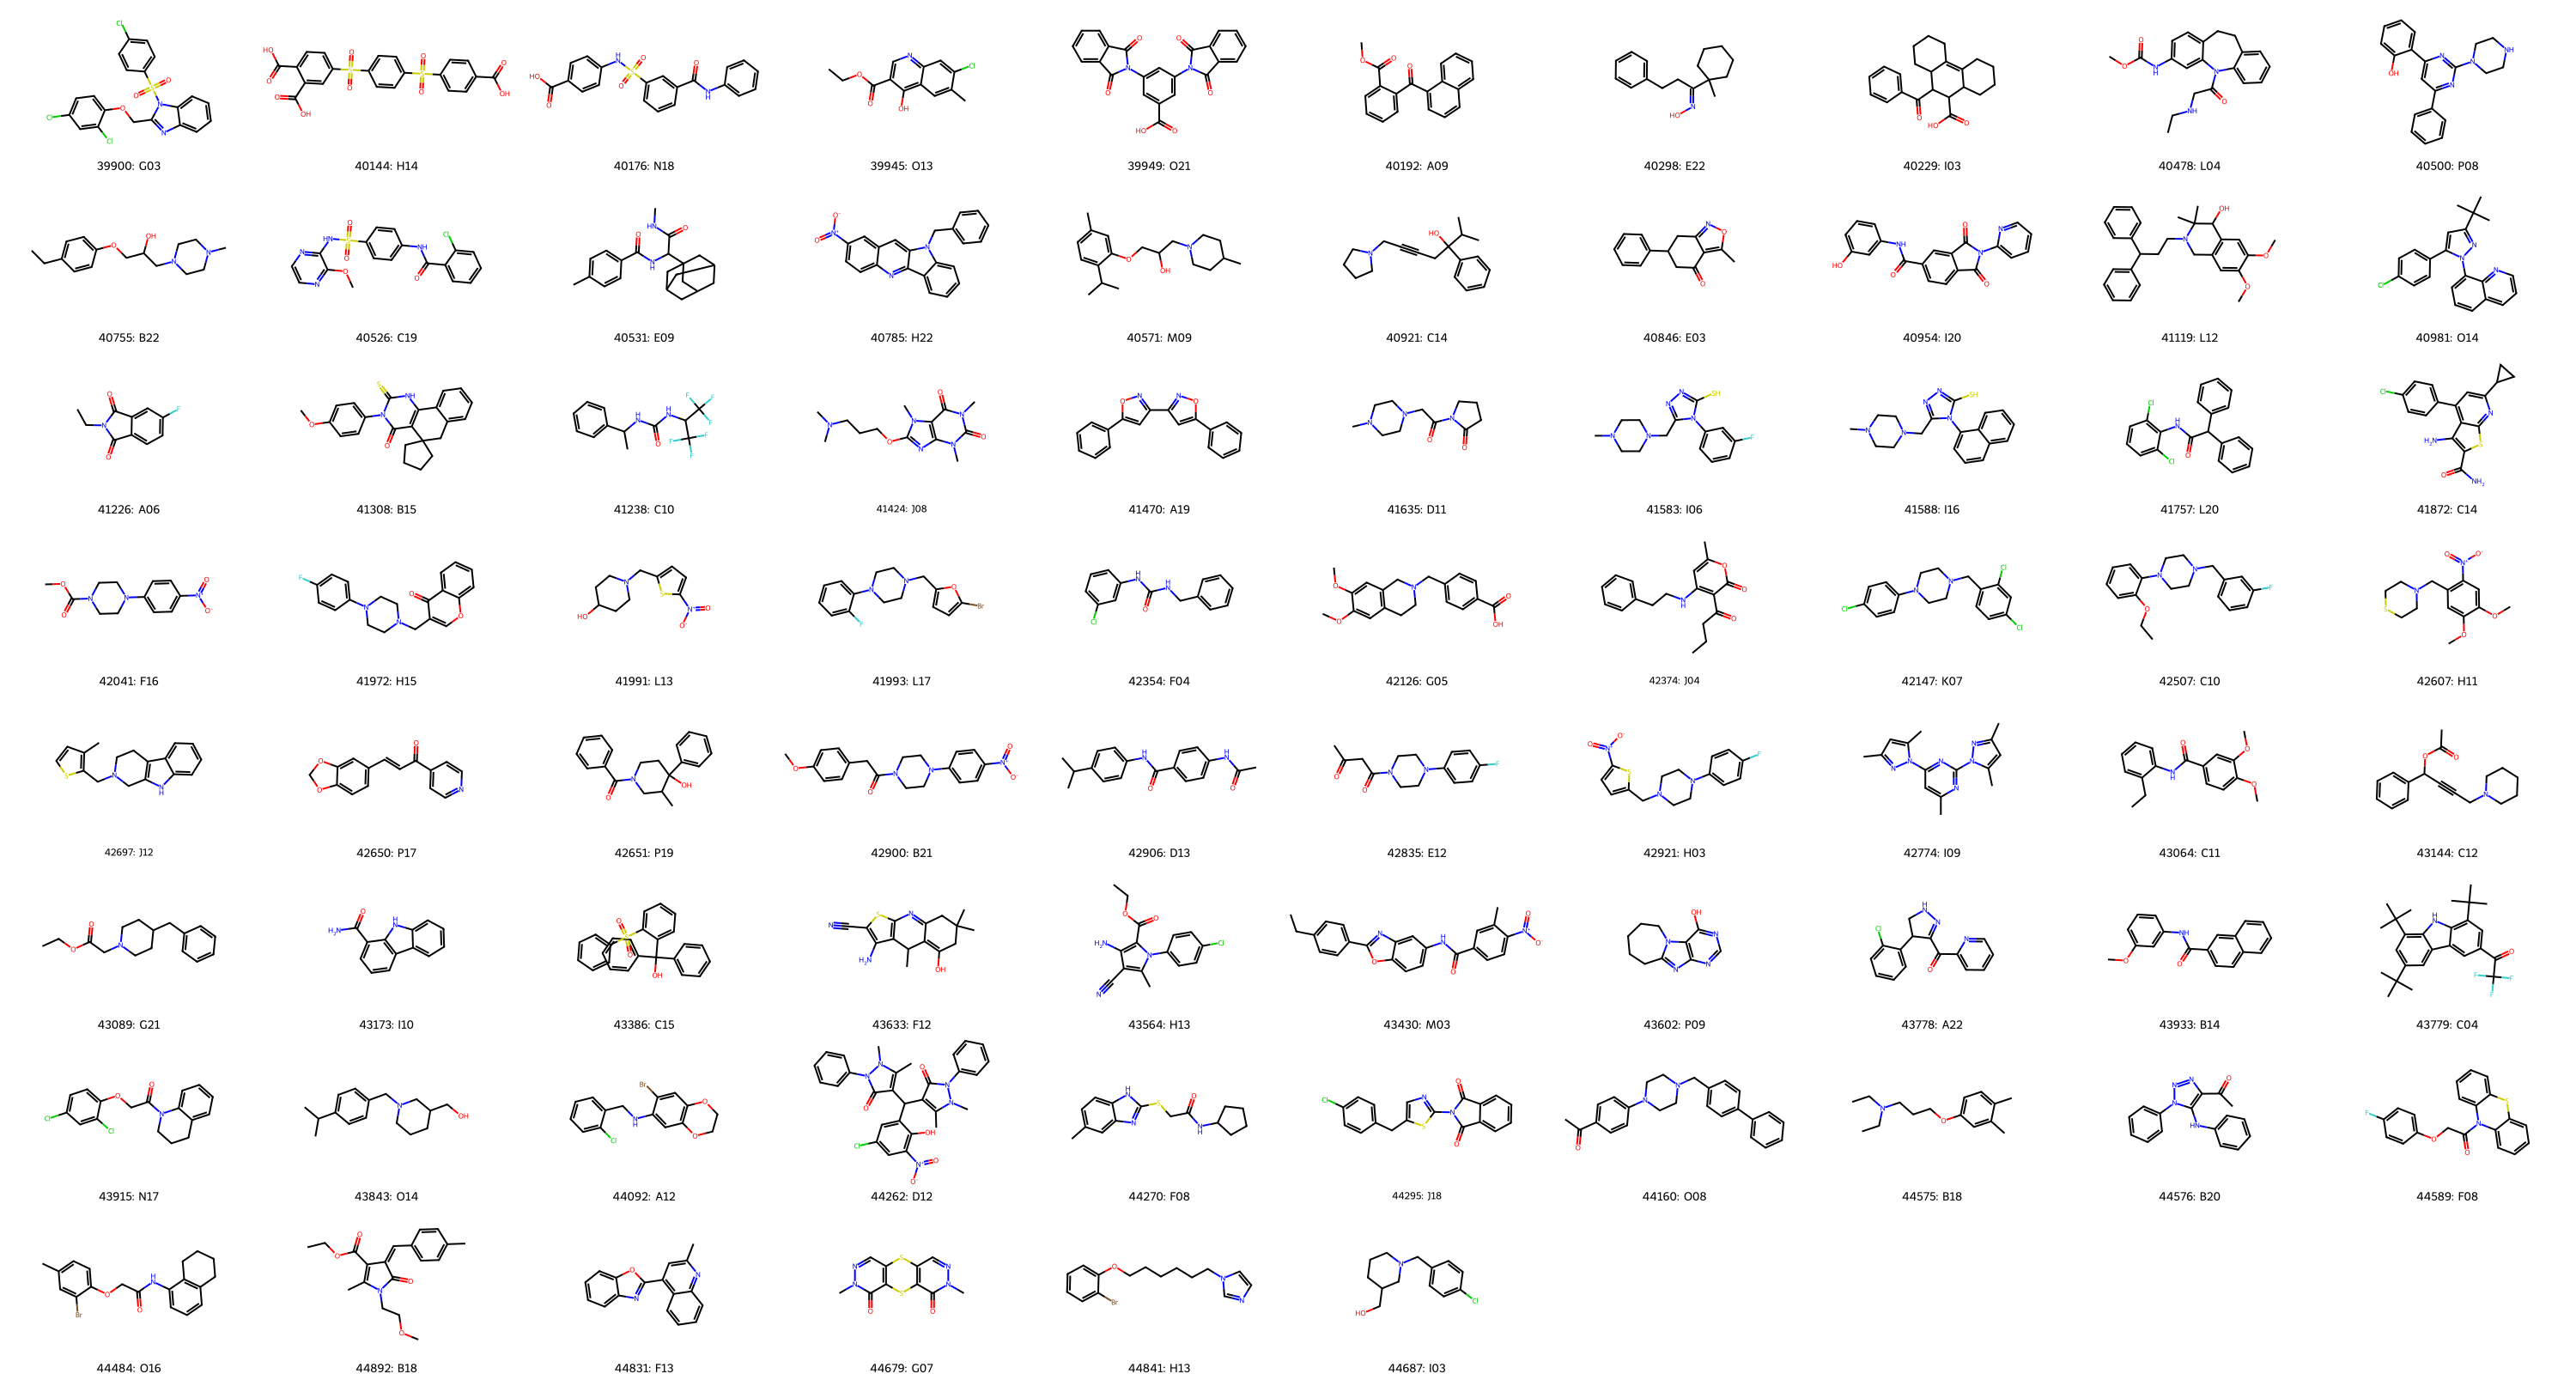

In [18]:
#draw molecules

from rdkit import Chem
from rdkit.Chem import Draw

mols=[Chem.MolFromSmiles(x) for x in low_peaks.SMILES]

labels=low_peaks.SMDC_ID.astype(int).astype(str).tolist()
labels=[labels[i]+": "+low_peaks.Well.iloc[i] for i in range(len(labels))]

opts = Draw.MolDrawOptions()
opts.legendFraction = 0.05  # Shrink label allocation (default is 0.1)
opts.padding = 0.01 # Reduce padding (default is 0.05)

Draw.MolsToGridImage(mols=mols, molsPerRow=10, subImgSize=(300,200), legends=labels, drawOptions=opts, maxMols=384)

/Users/echun/repos/diversity-library-qc/./scripts/analyze_lcms.py:64: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1, figsize=(15,4))


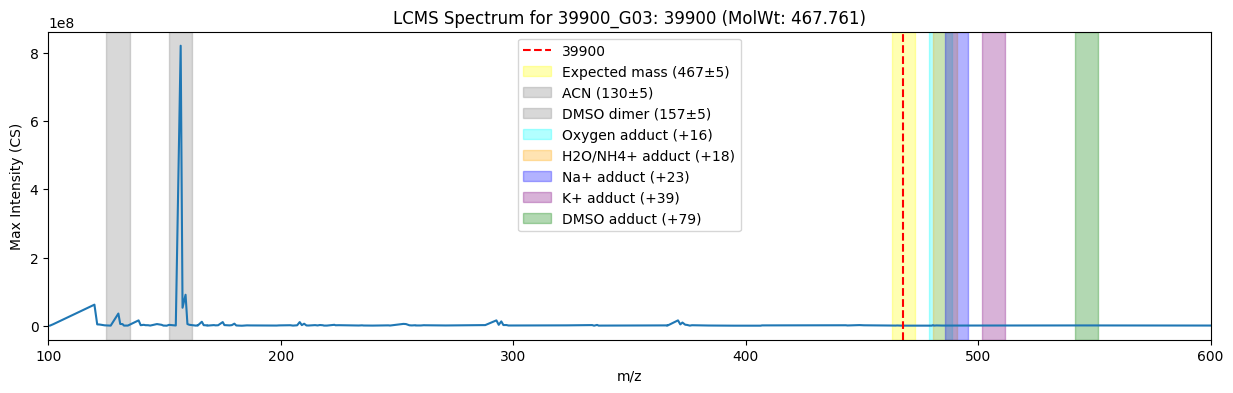

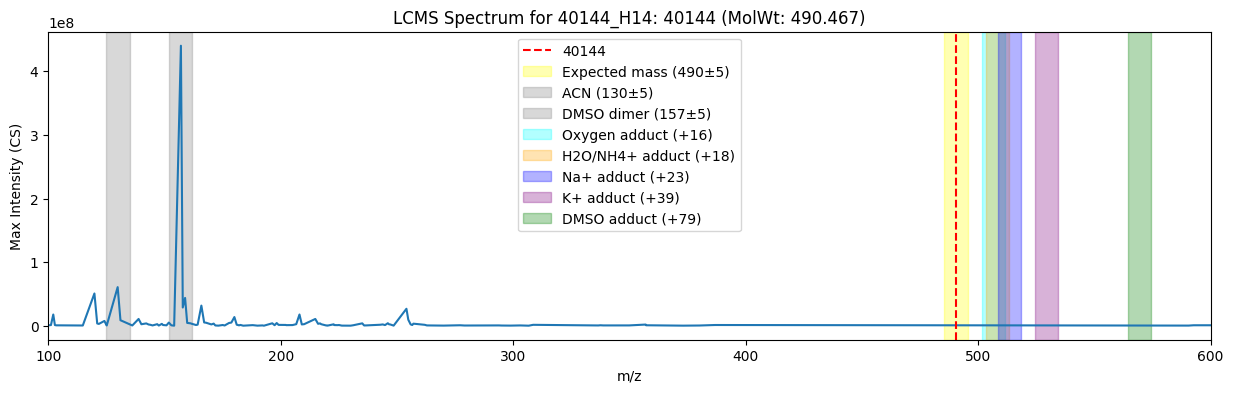

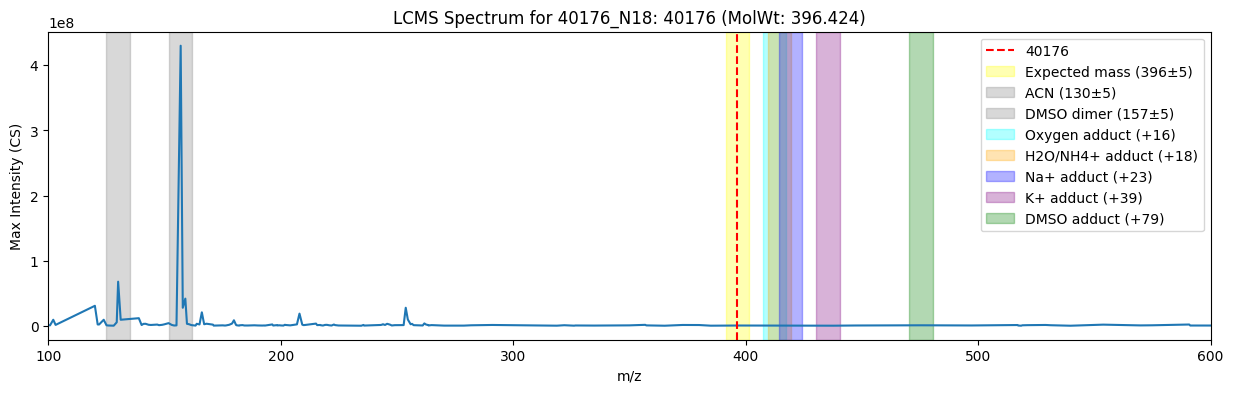

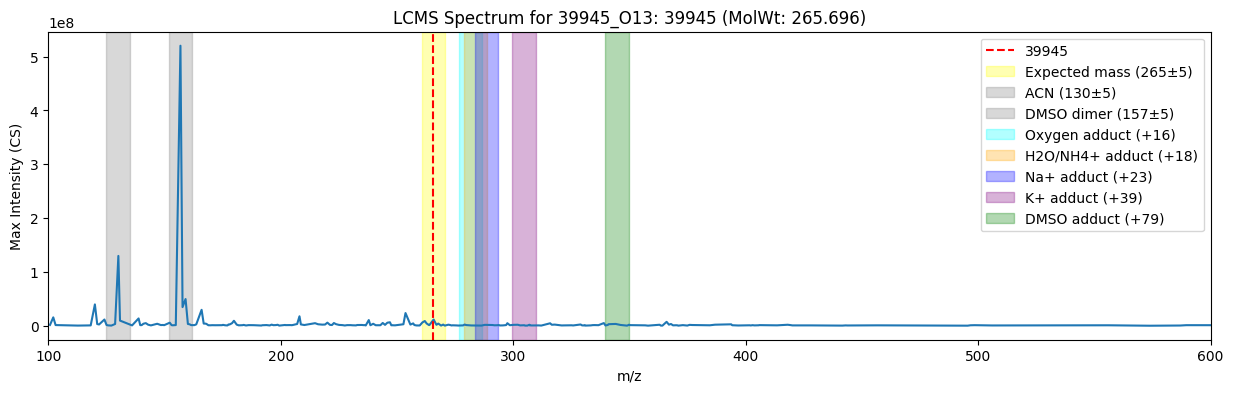

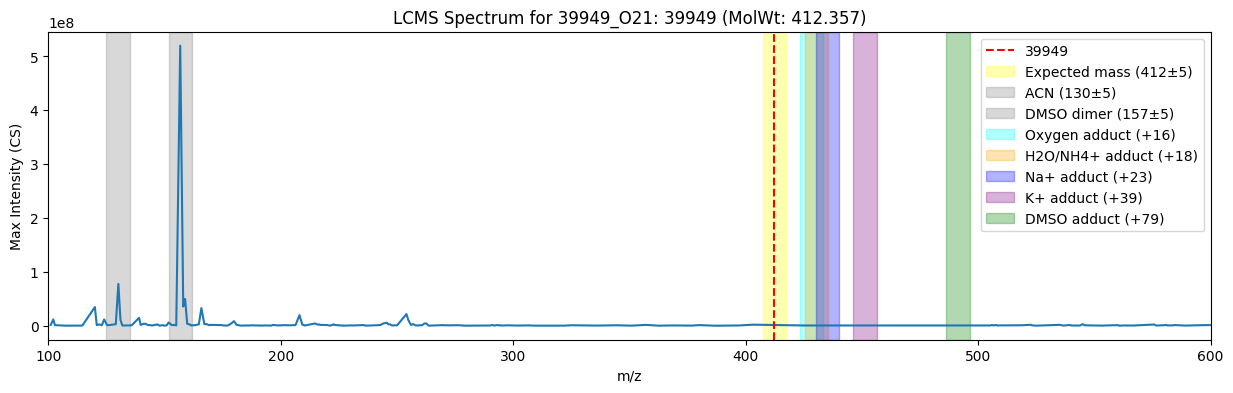

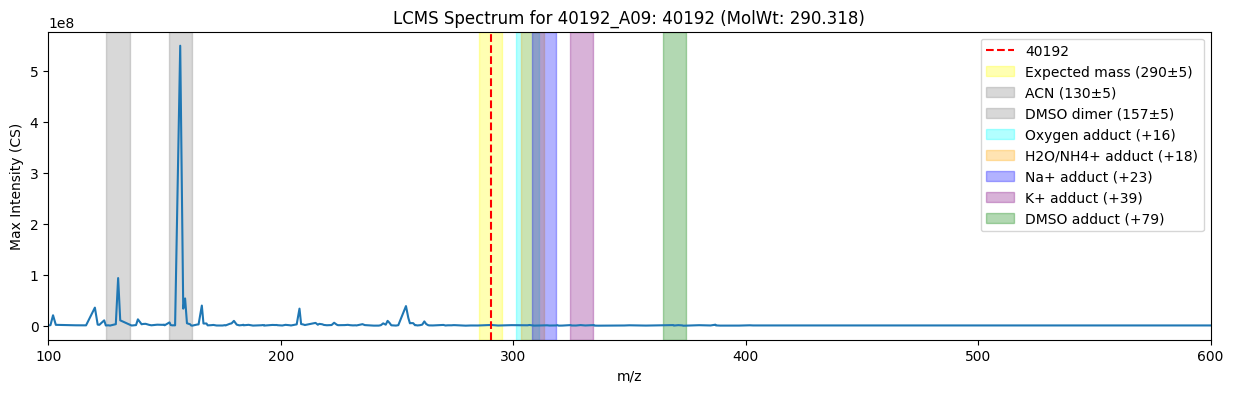

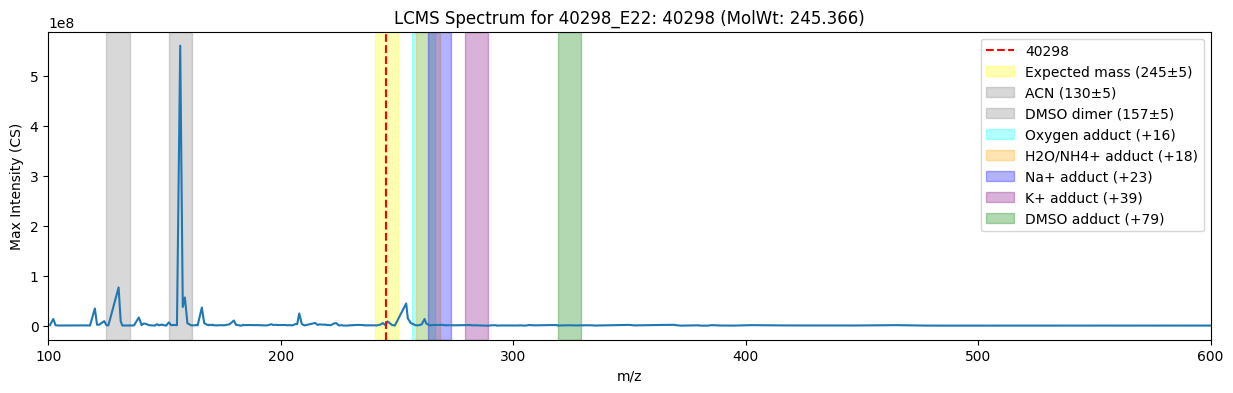

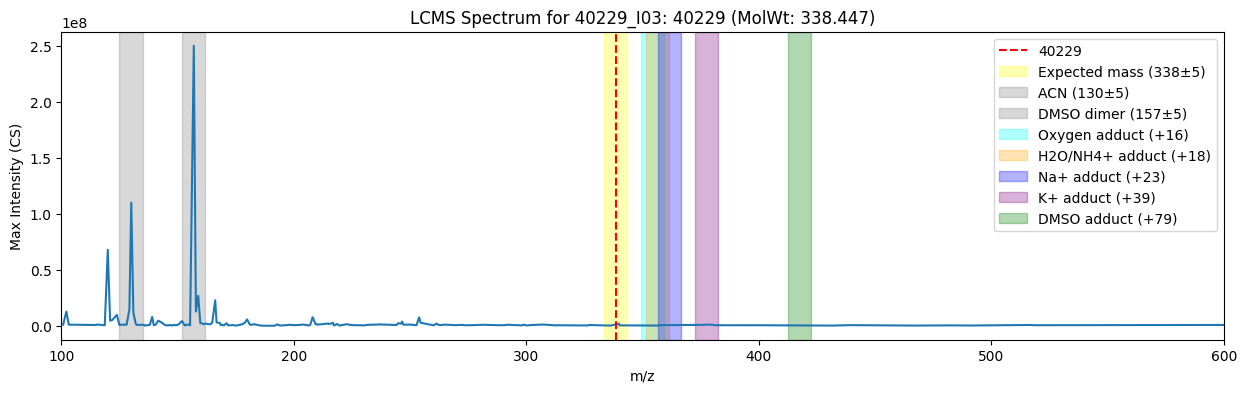

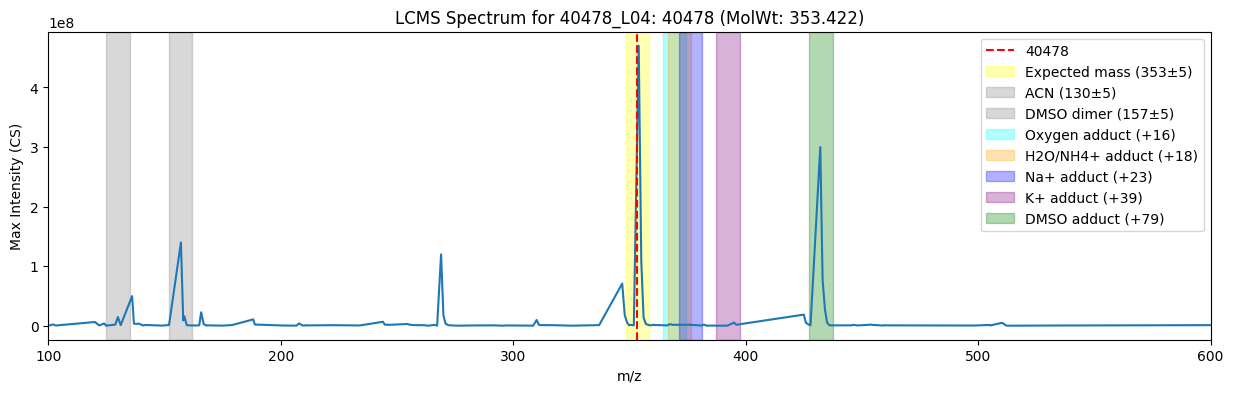

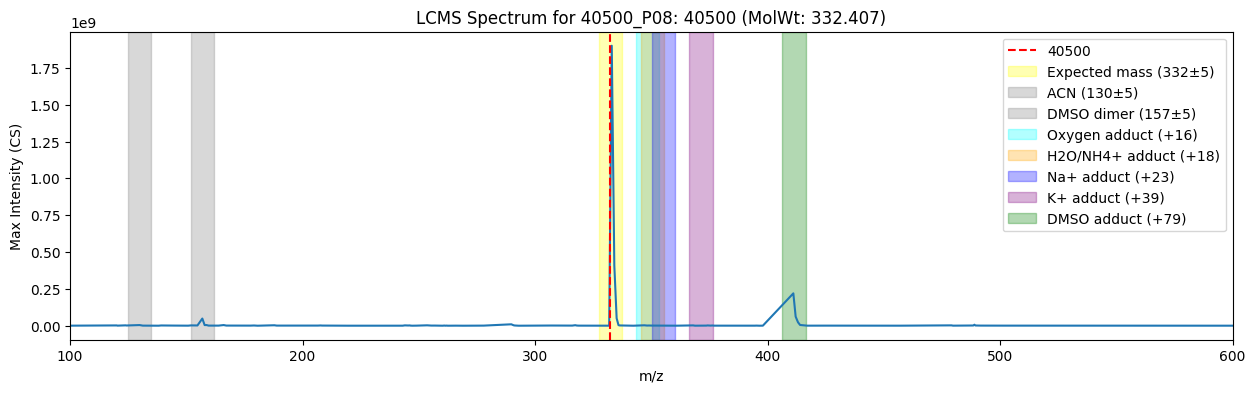

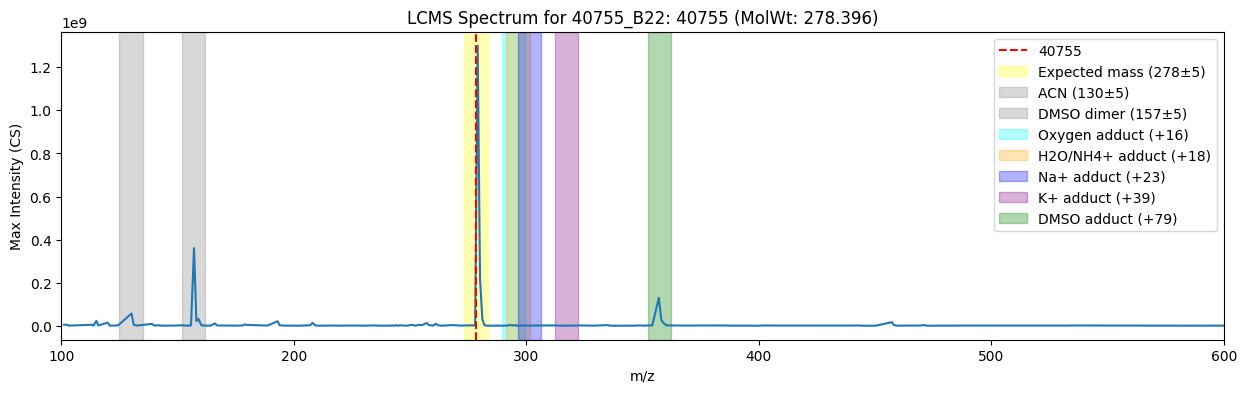

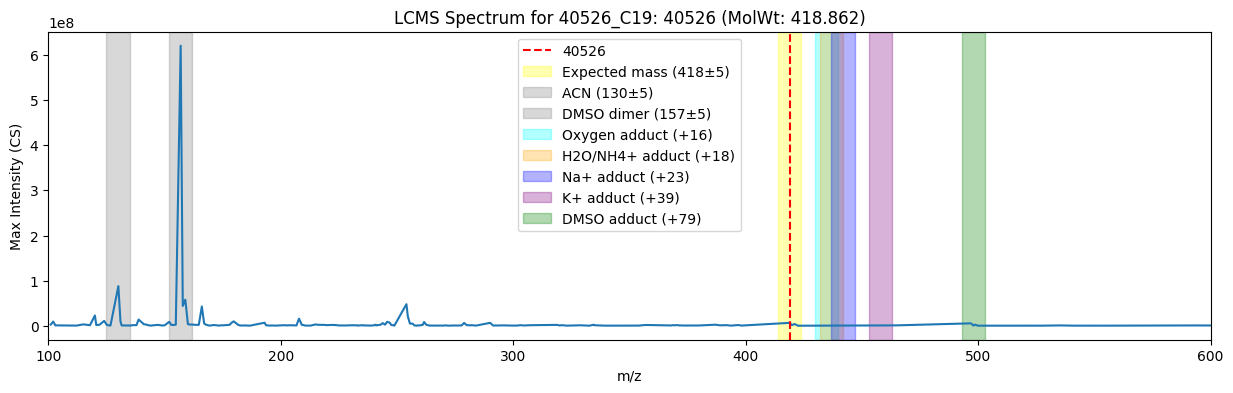

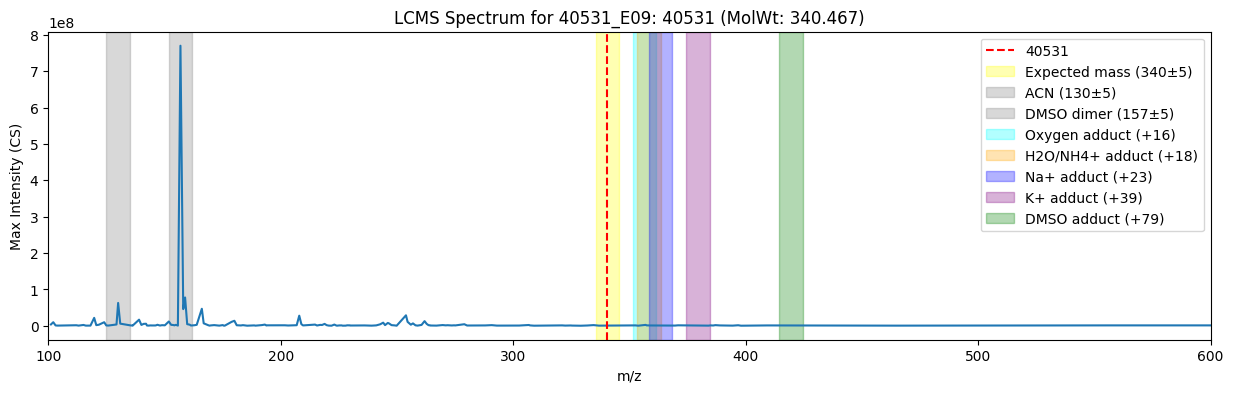

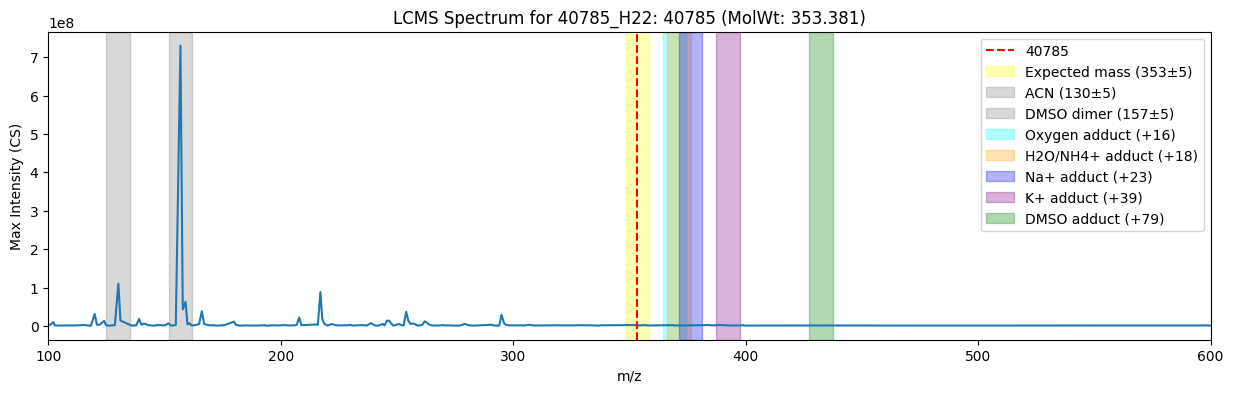

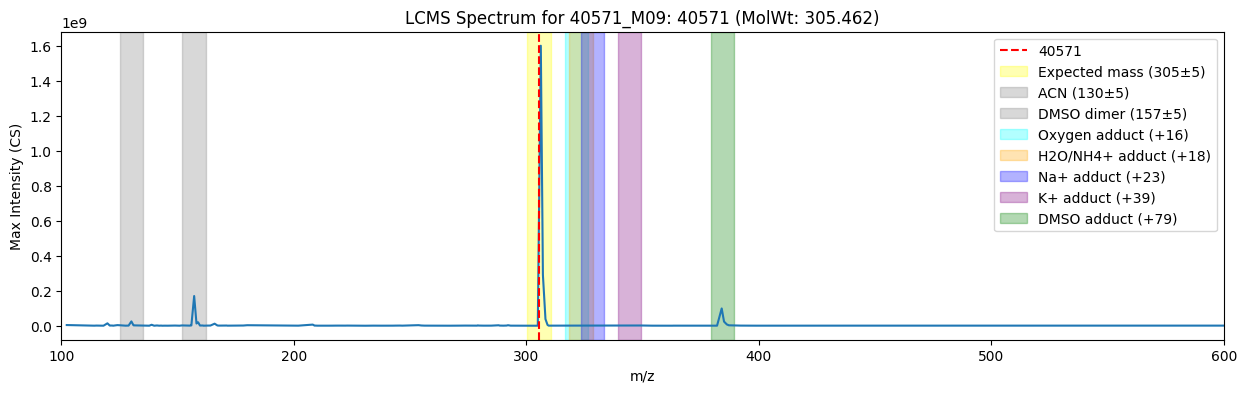

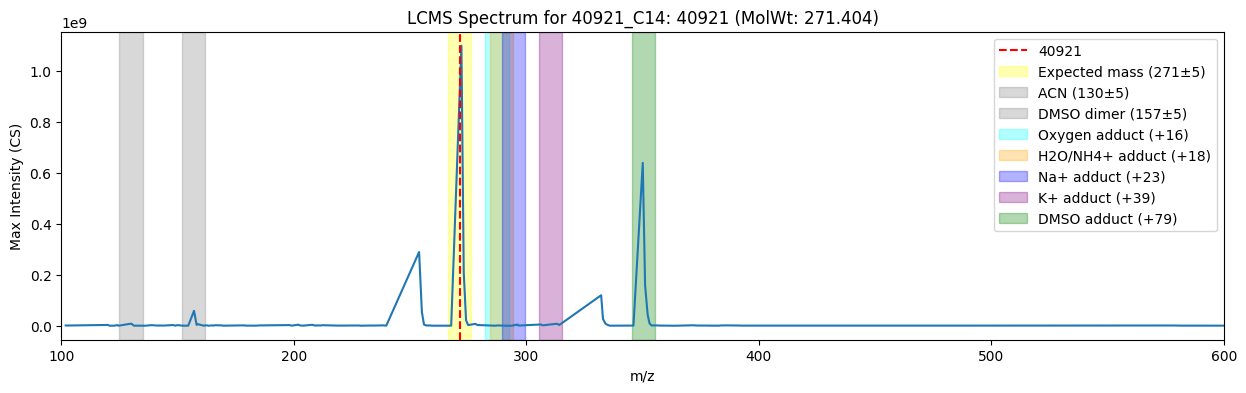

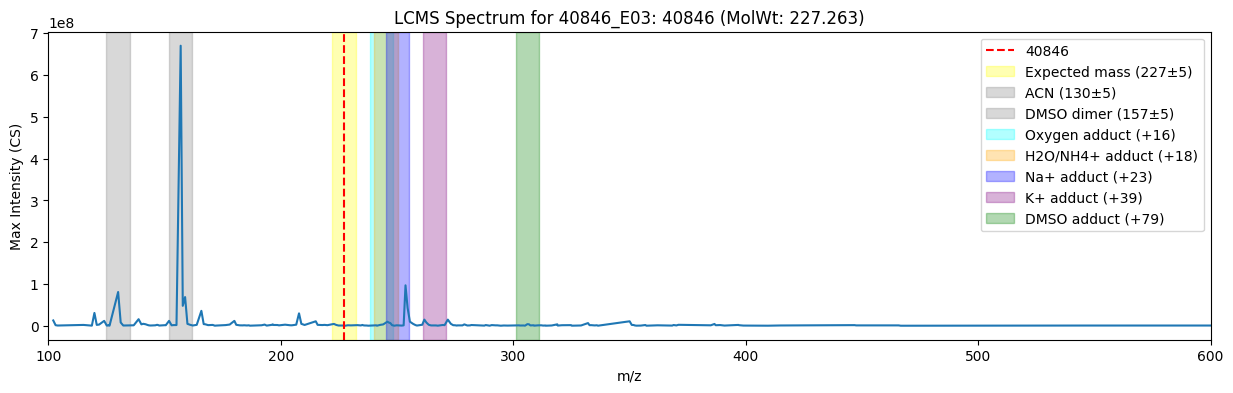

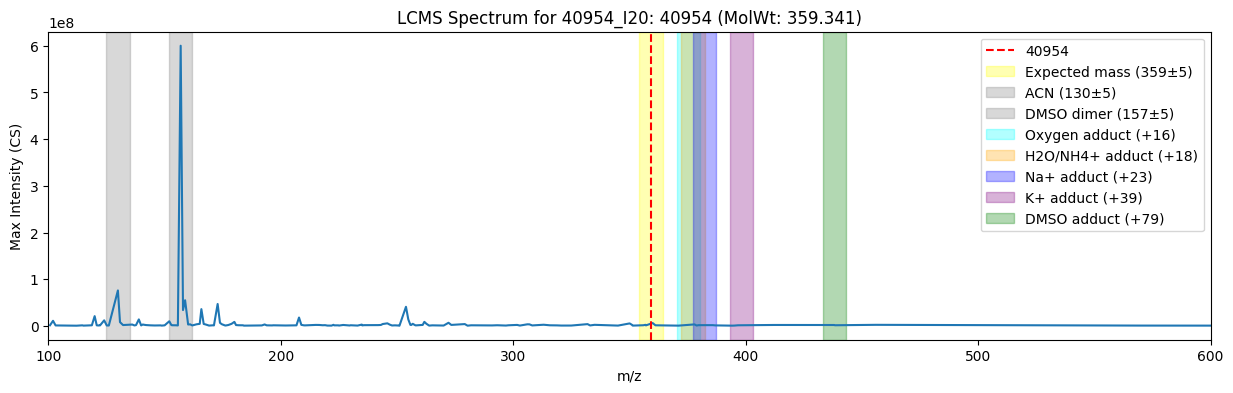

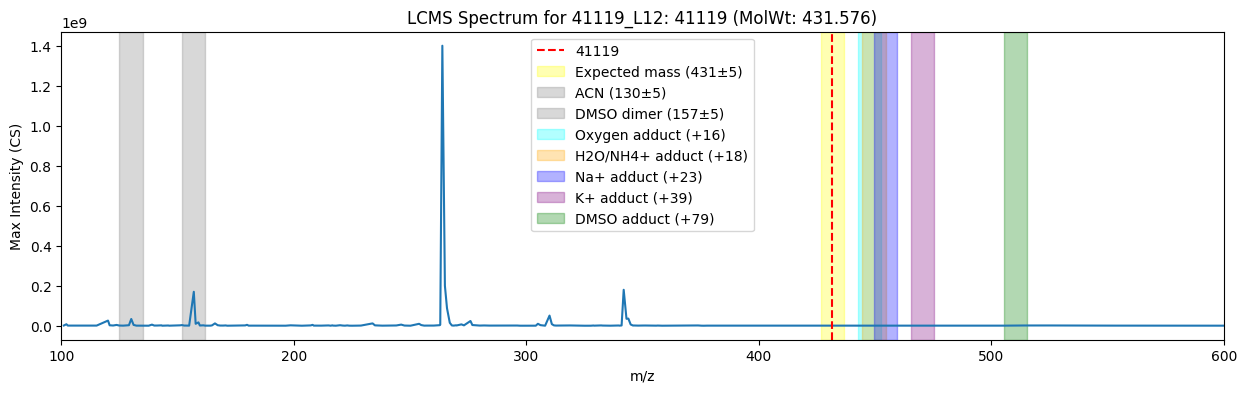

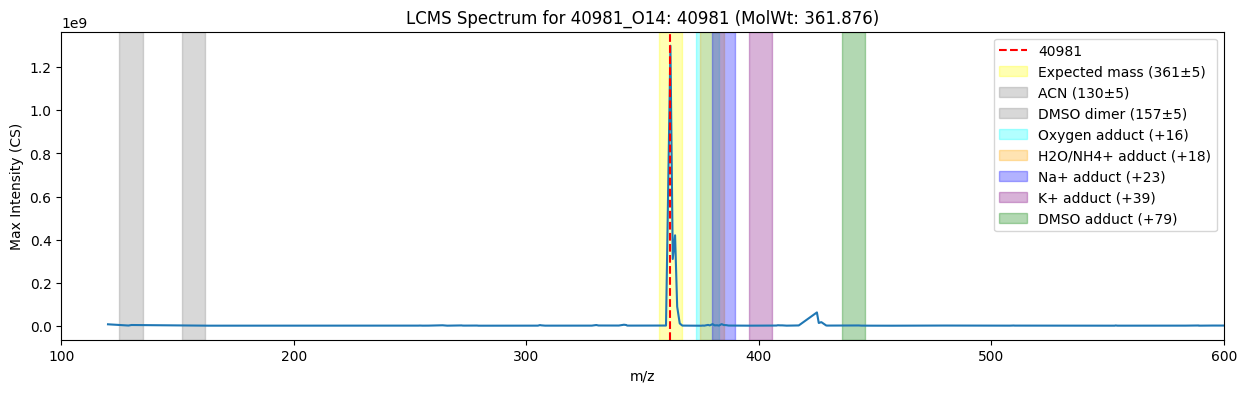

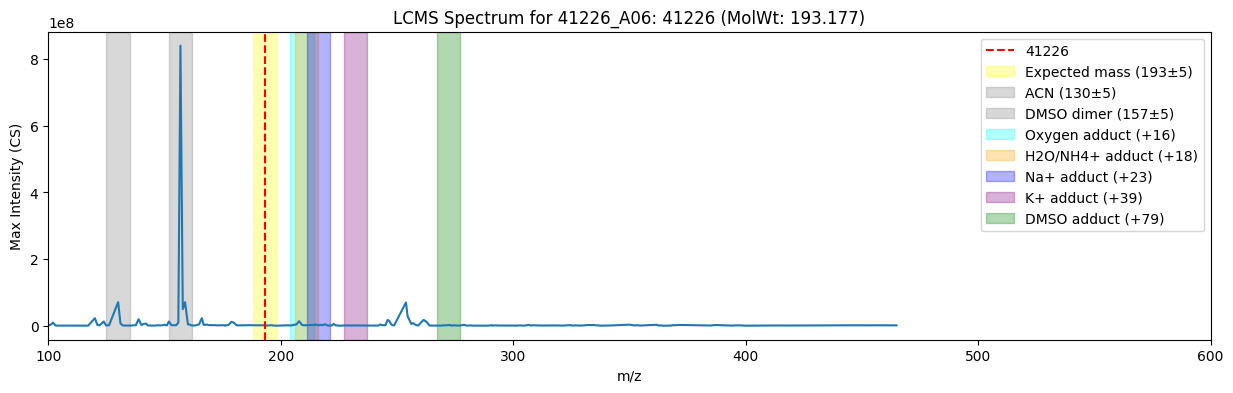

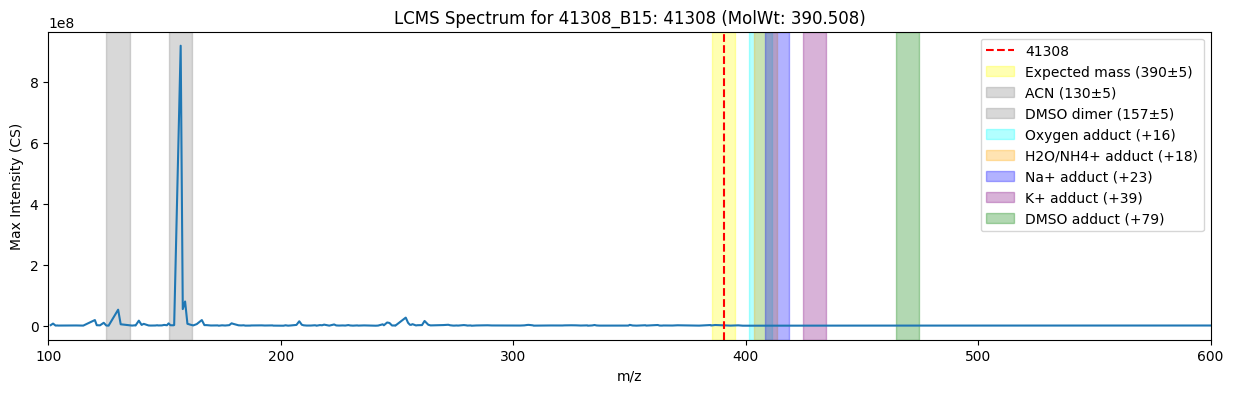

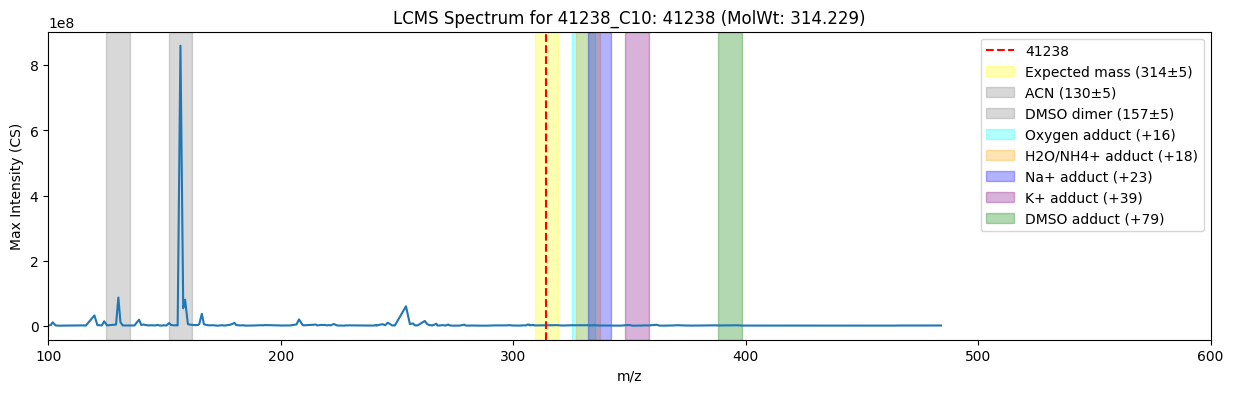

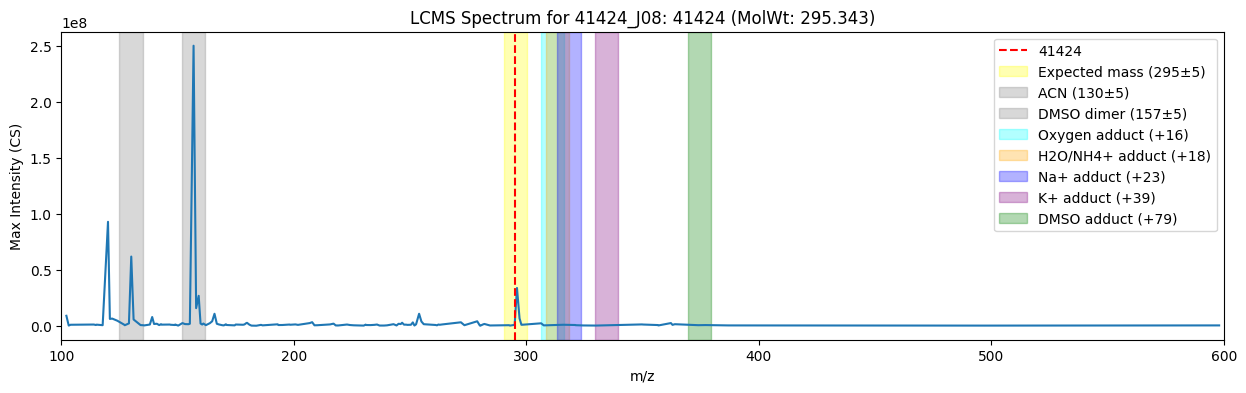

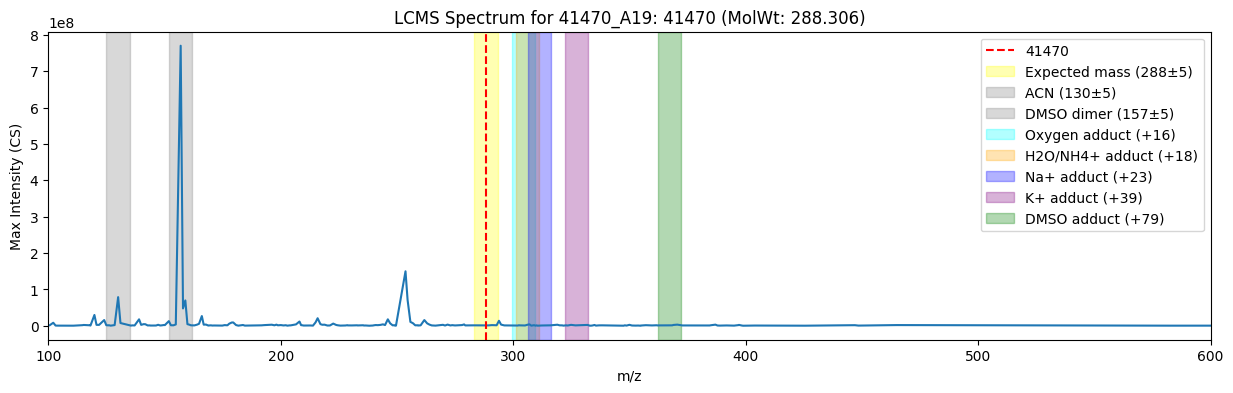

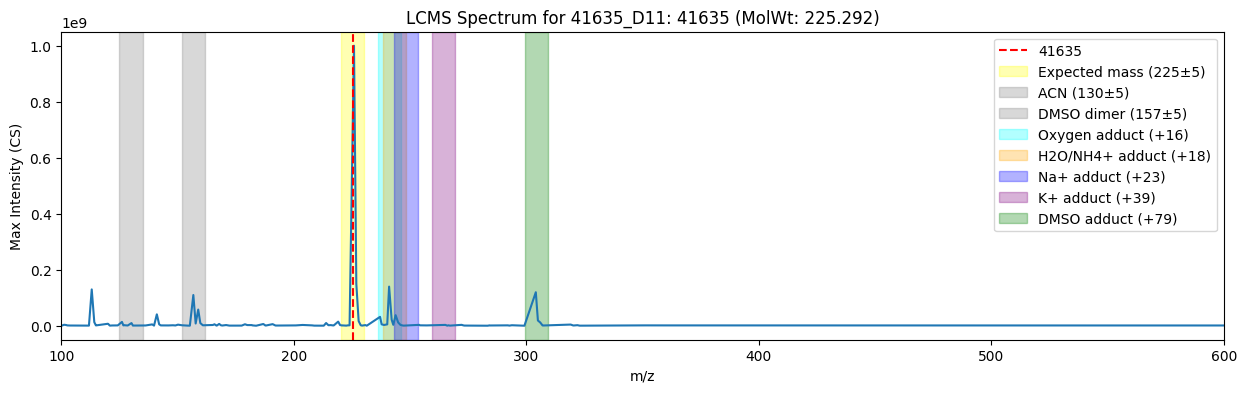

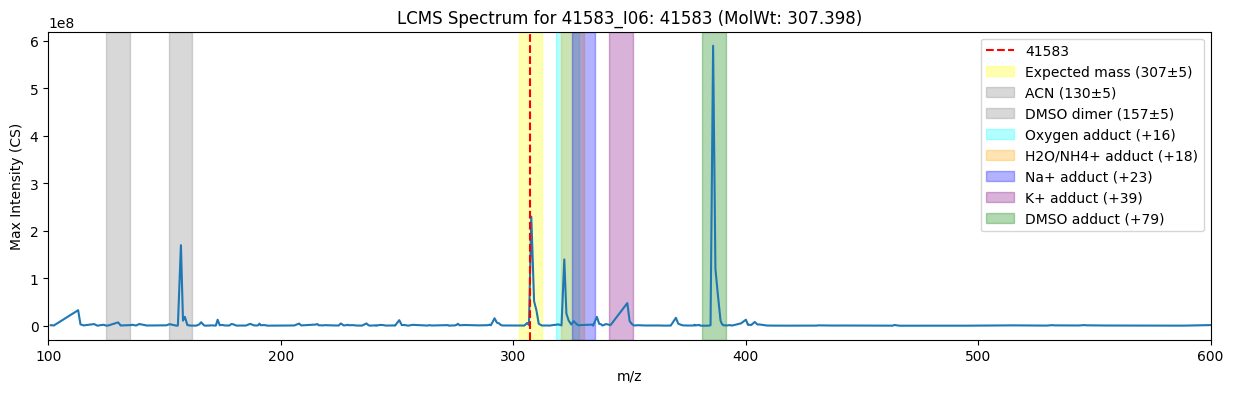

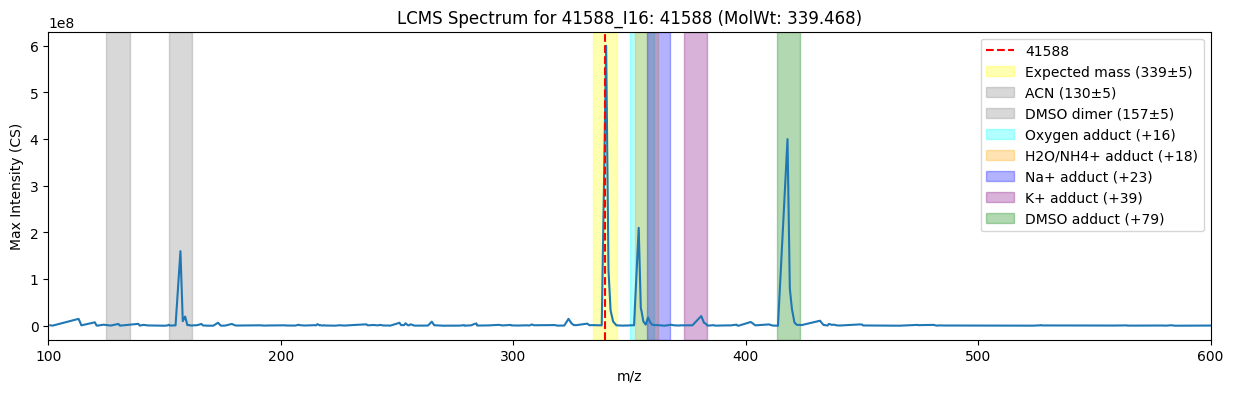

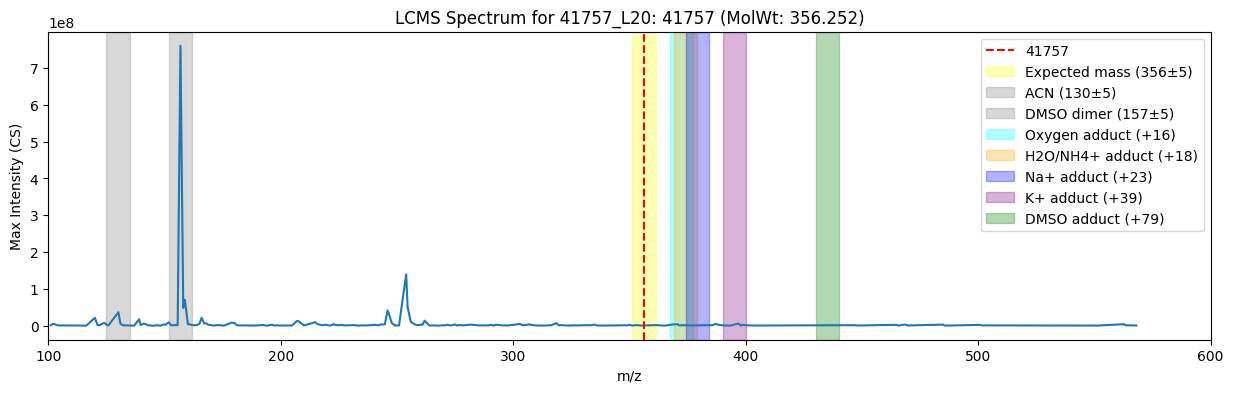

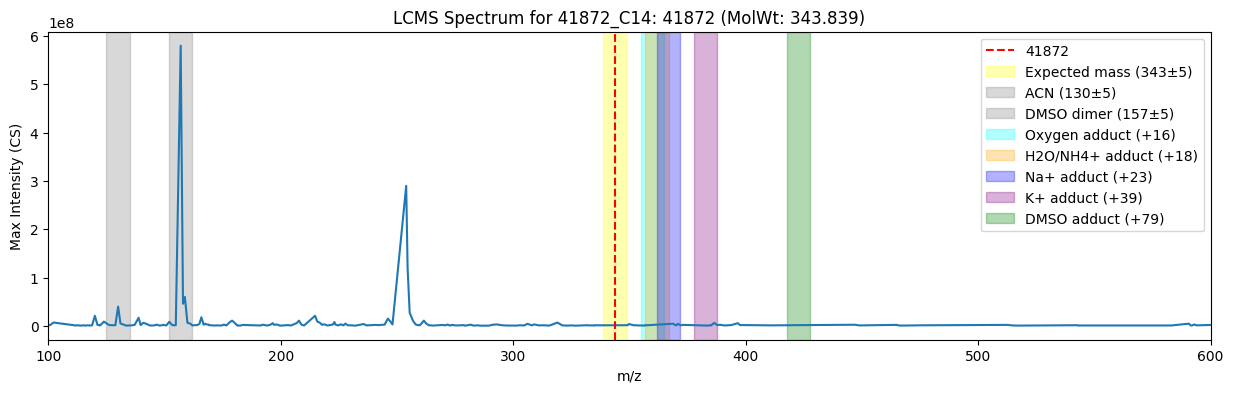

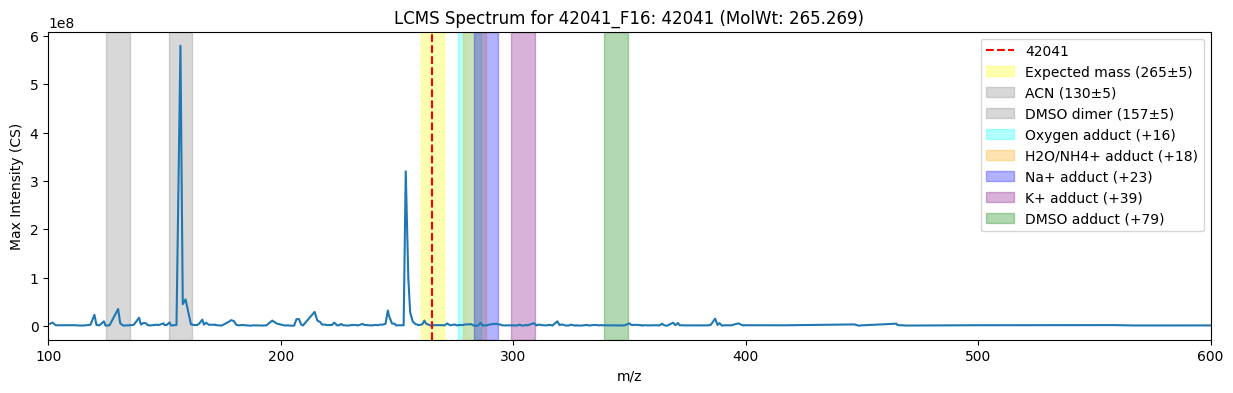

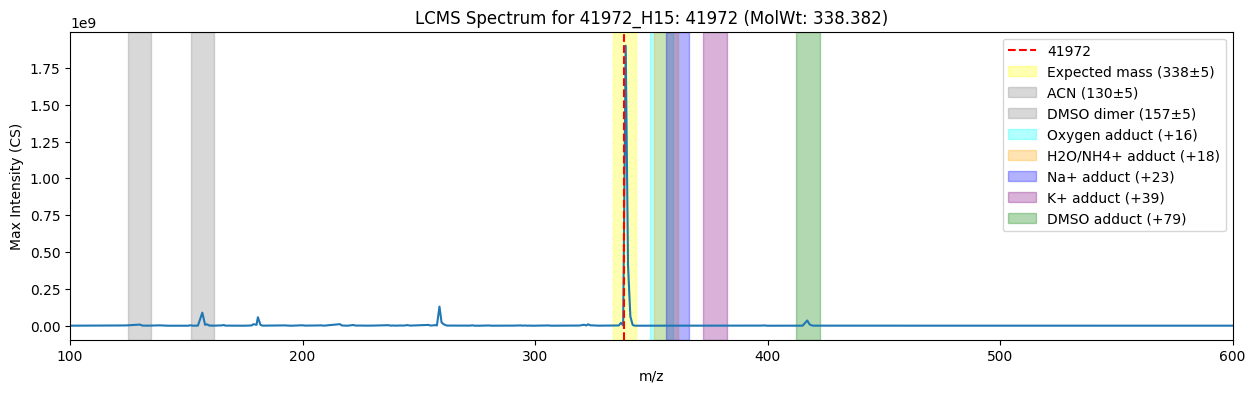

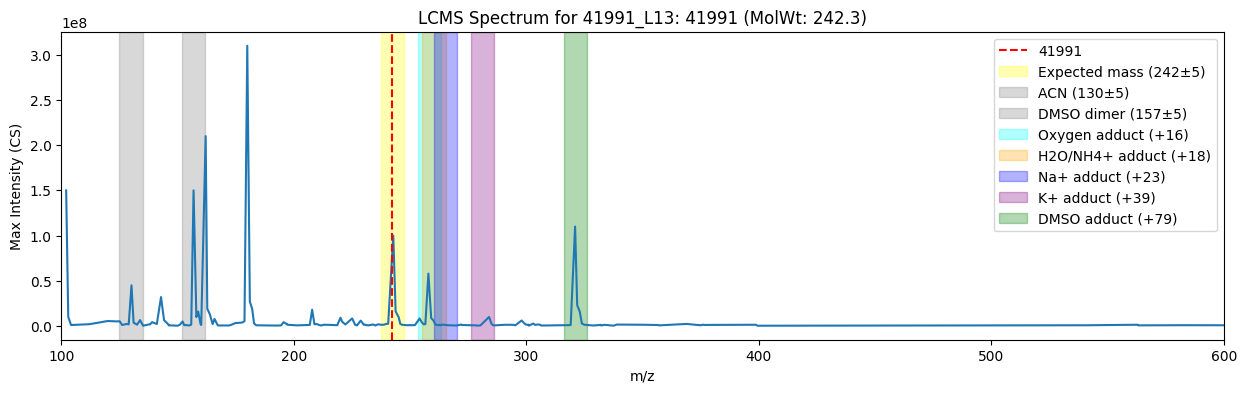

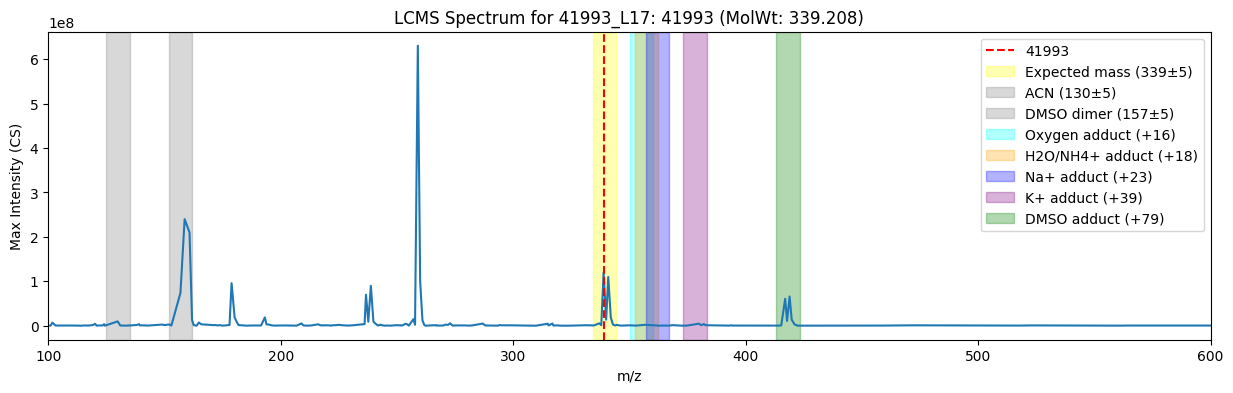

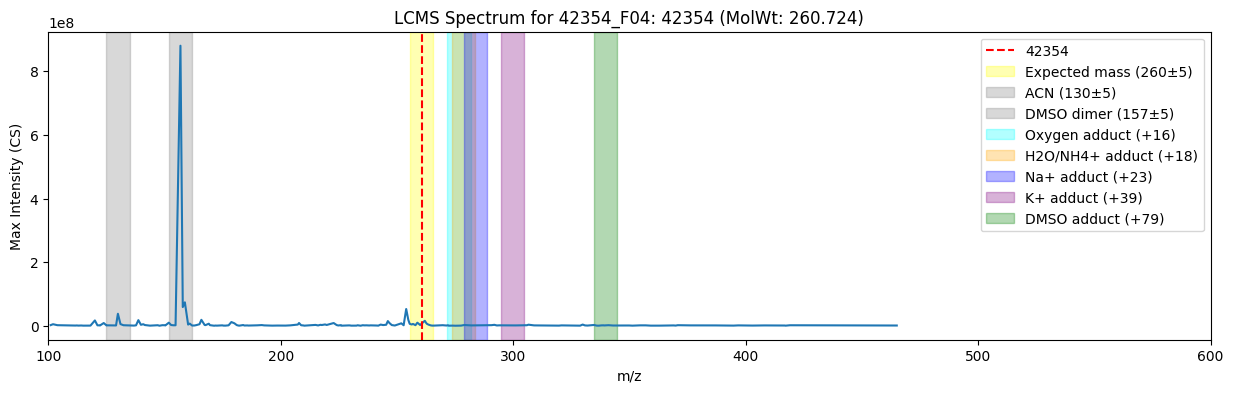

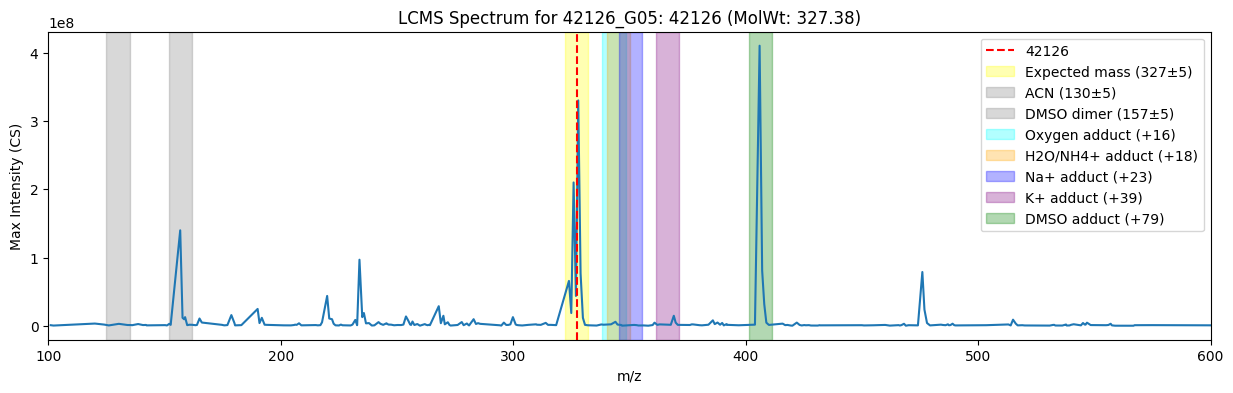

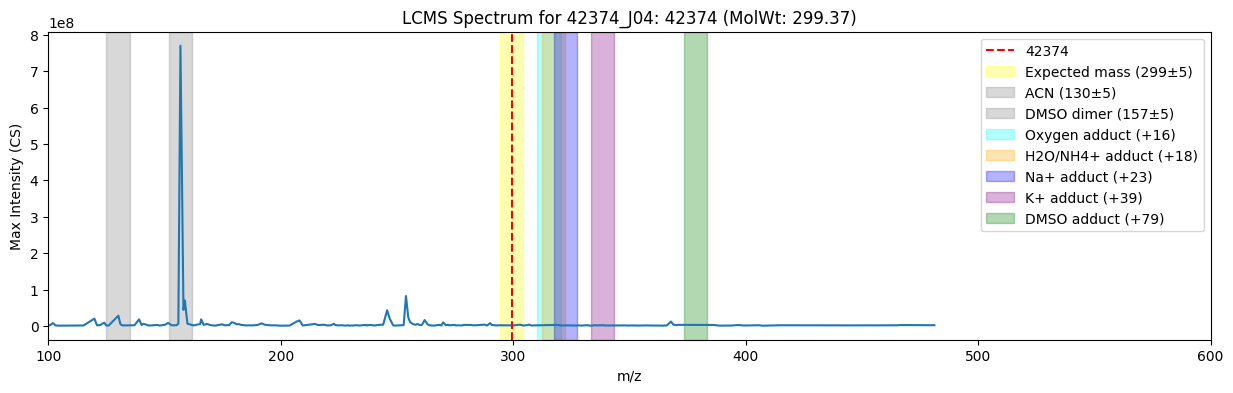

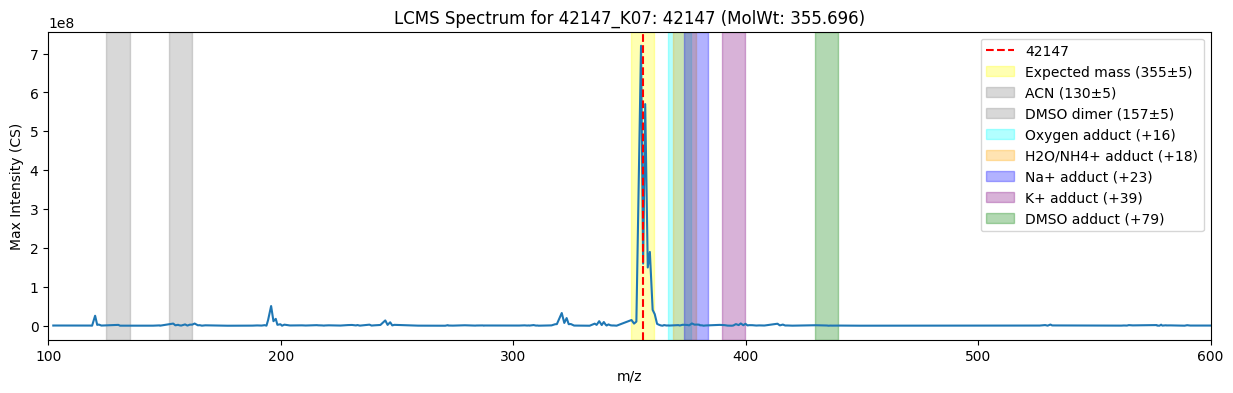

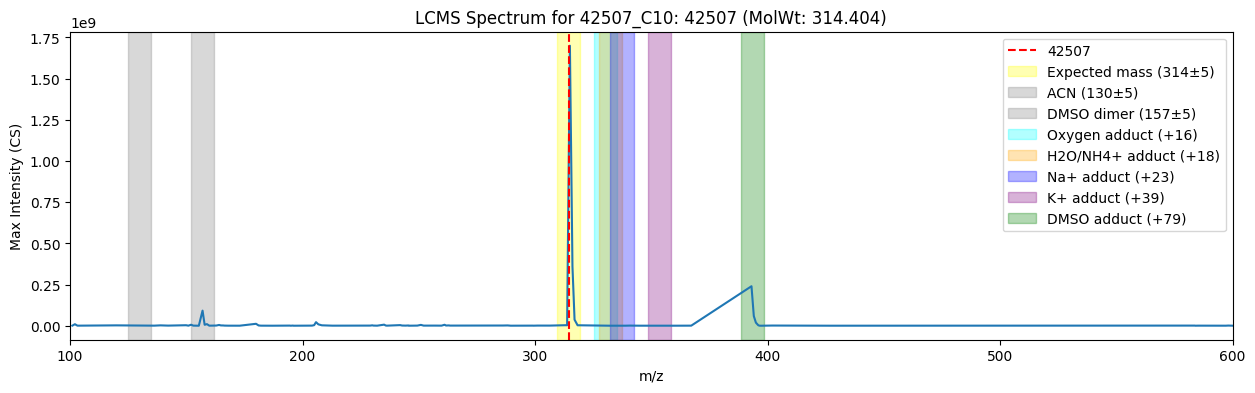

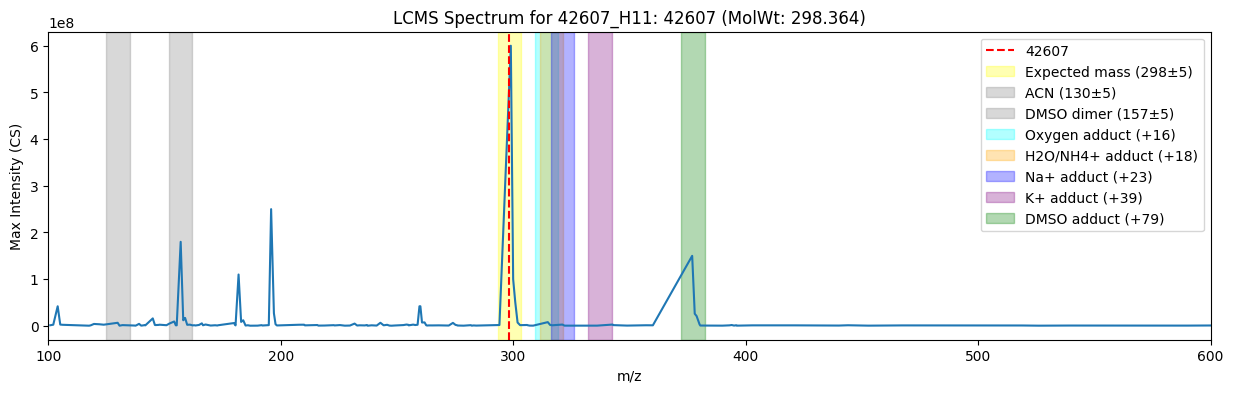

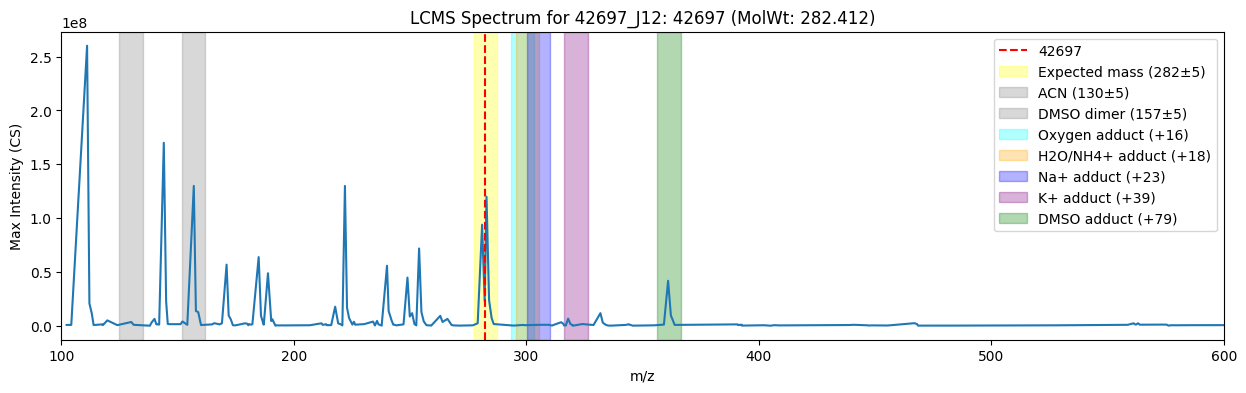

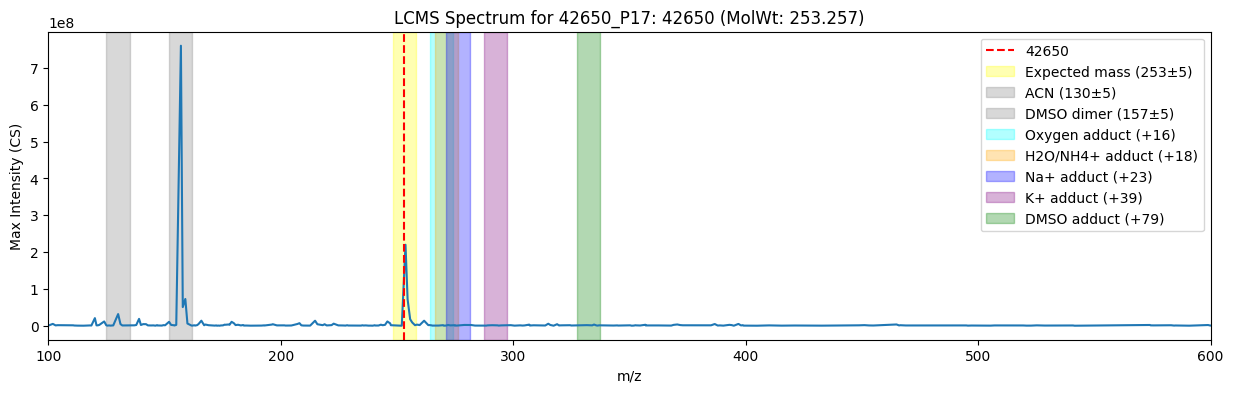

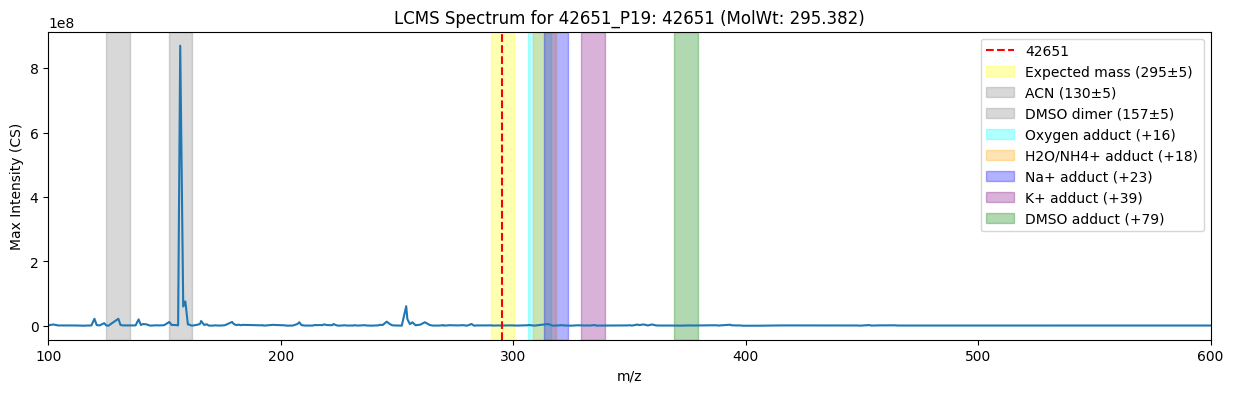

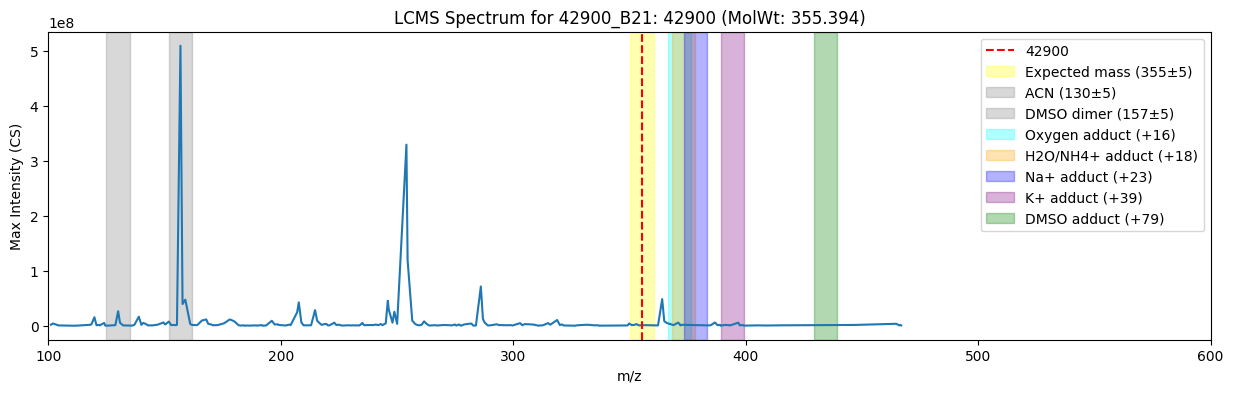

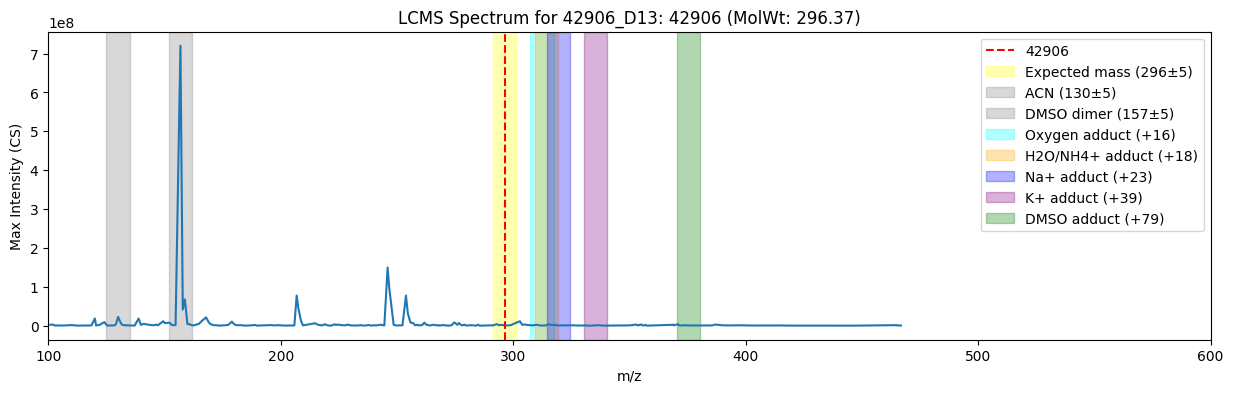

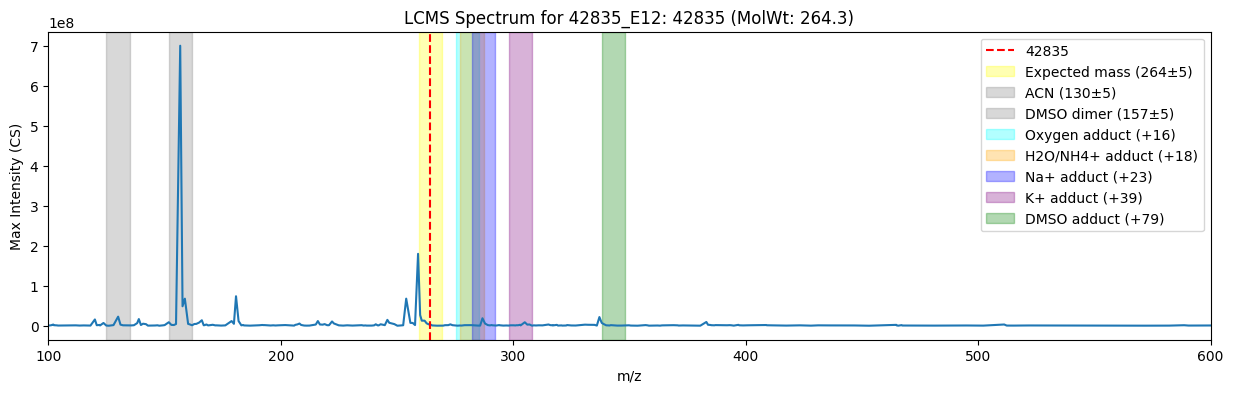

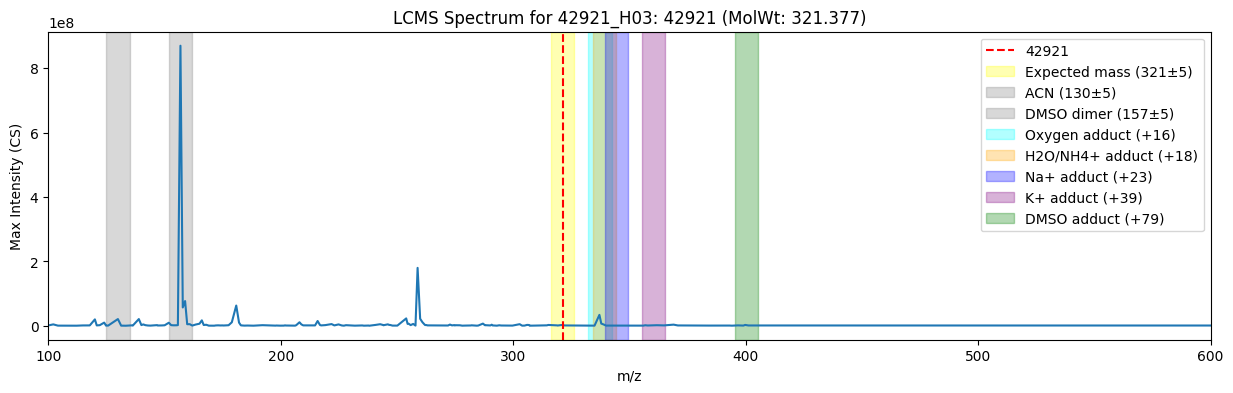

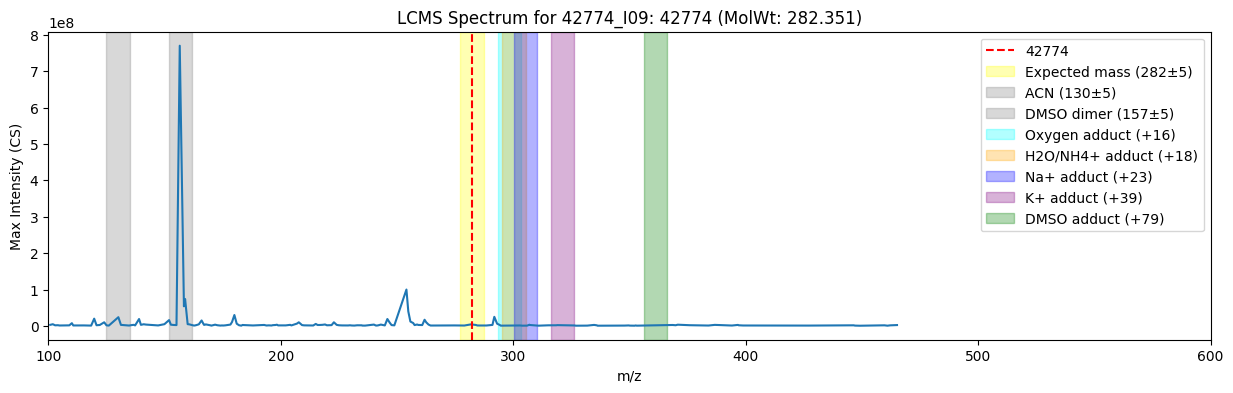

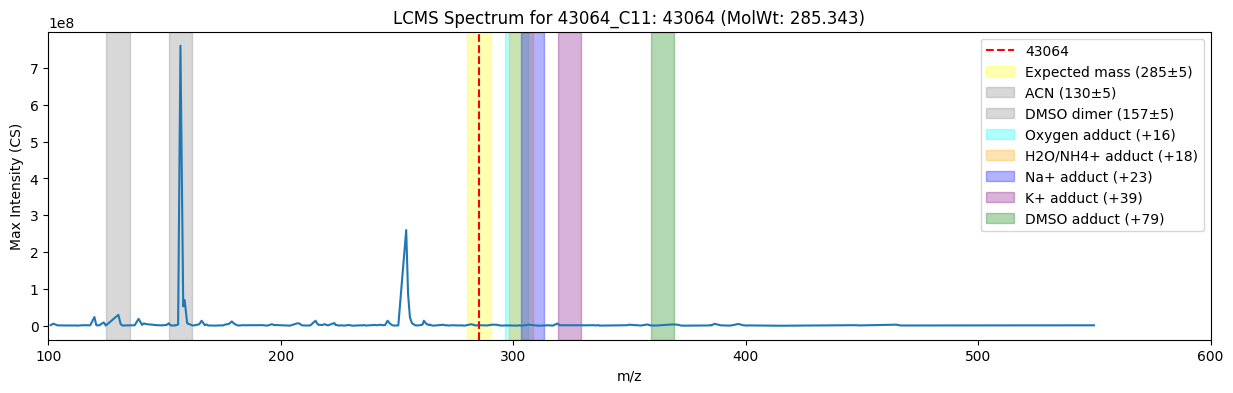

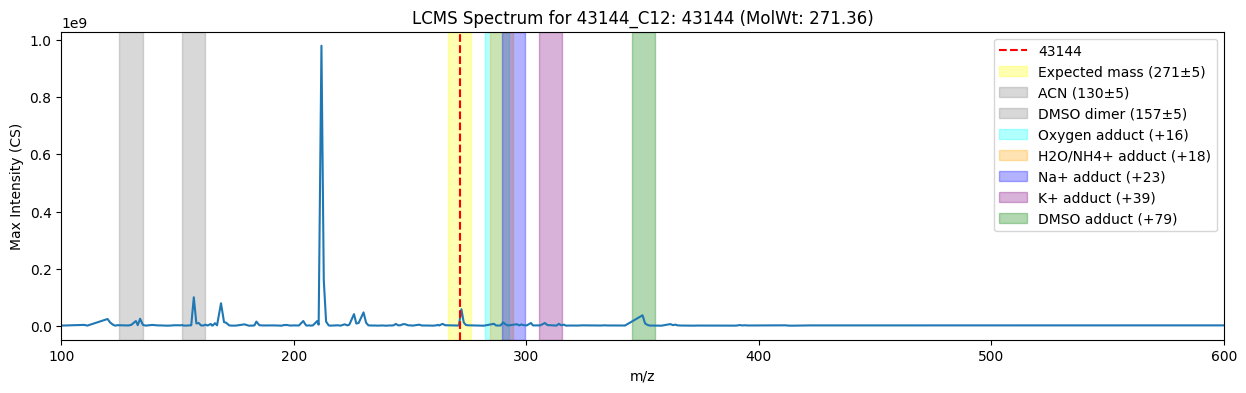

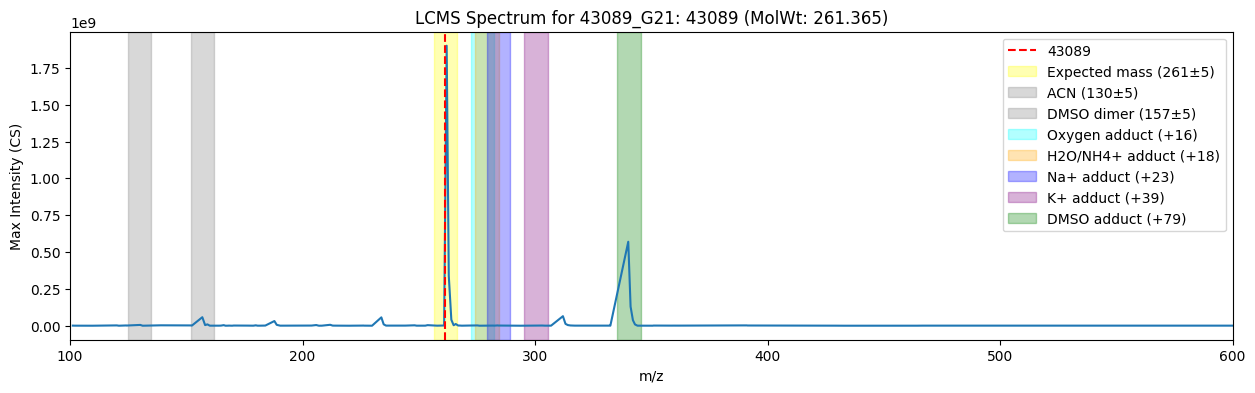

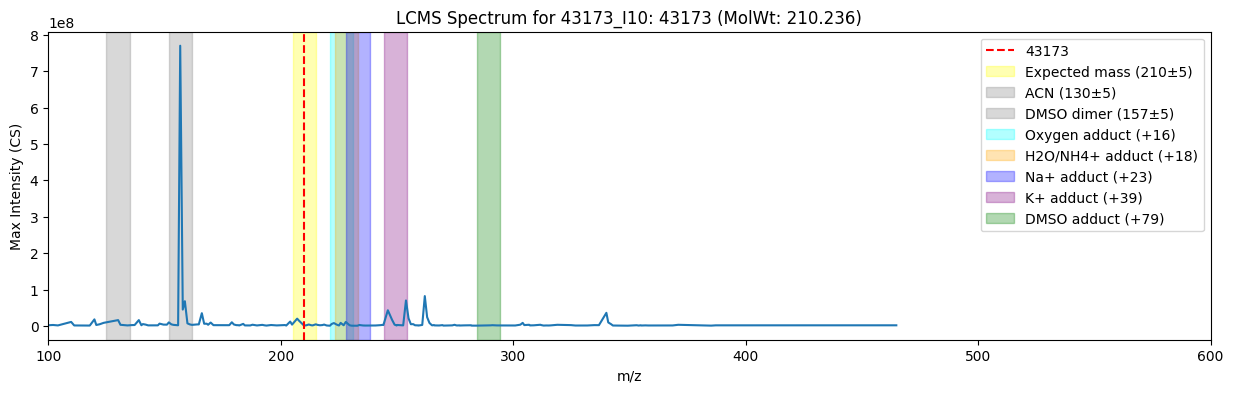

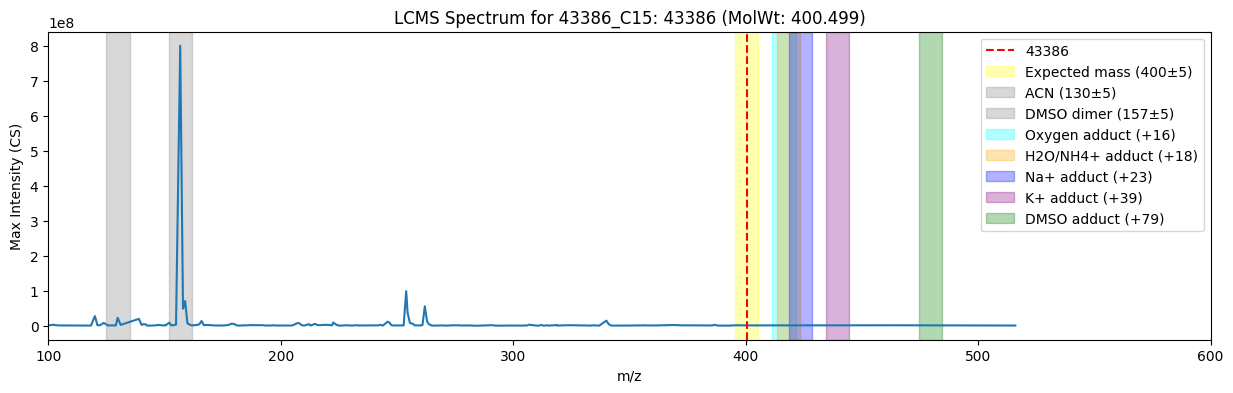

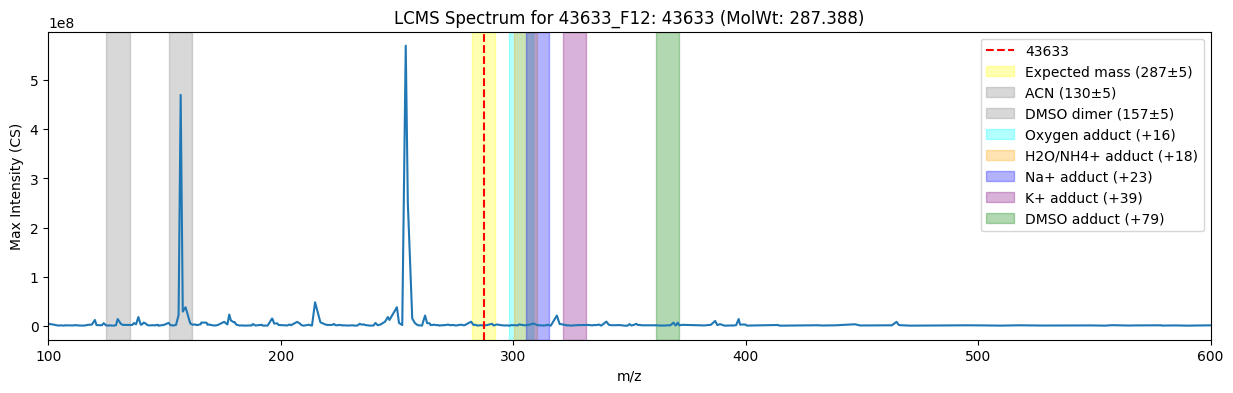

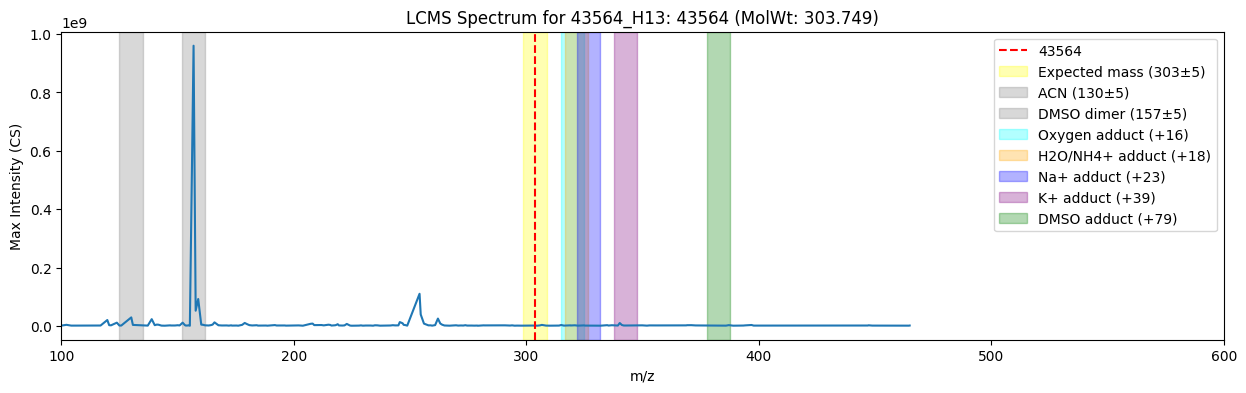

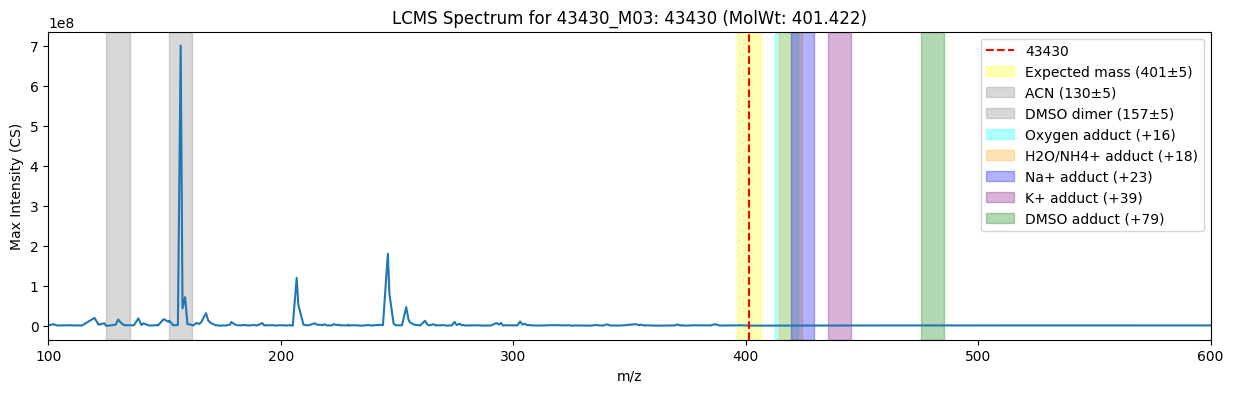

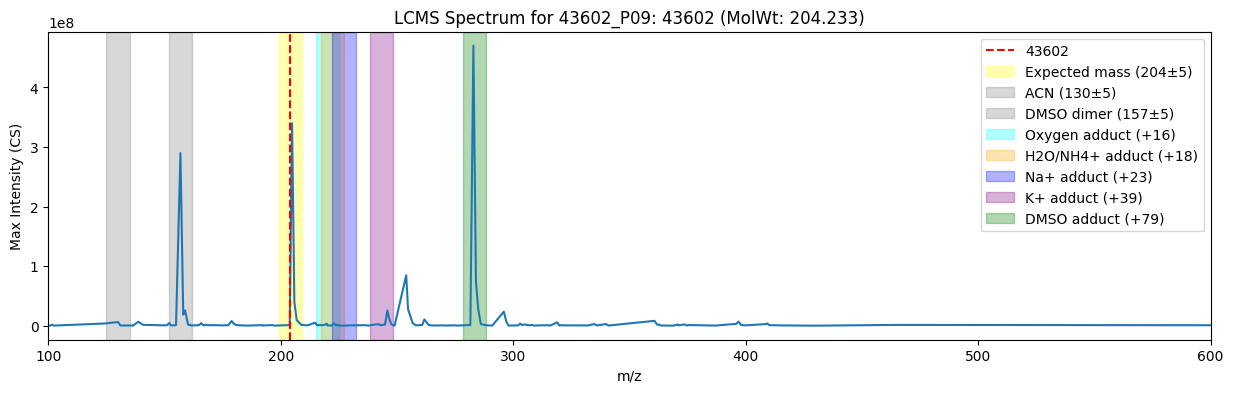

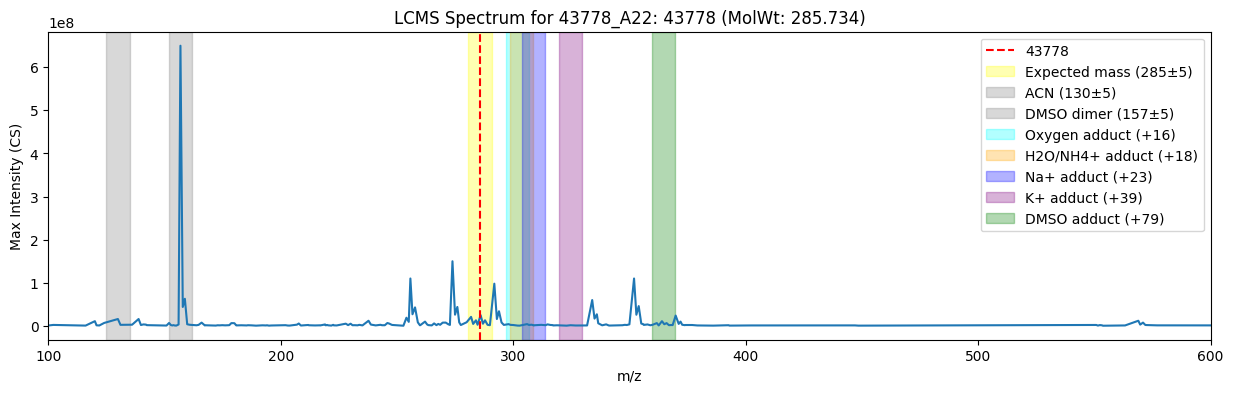

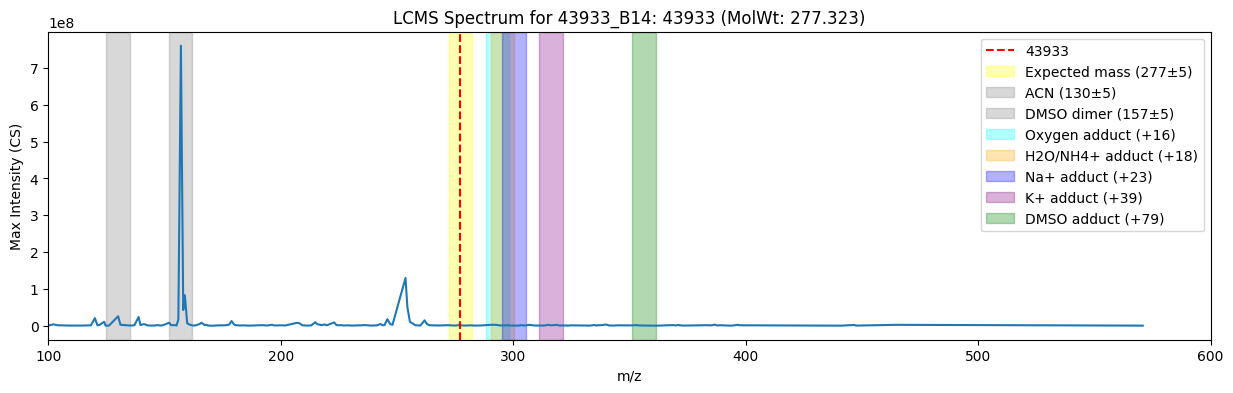

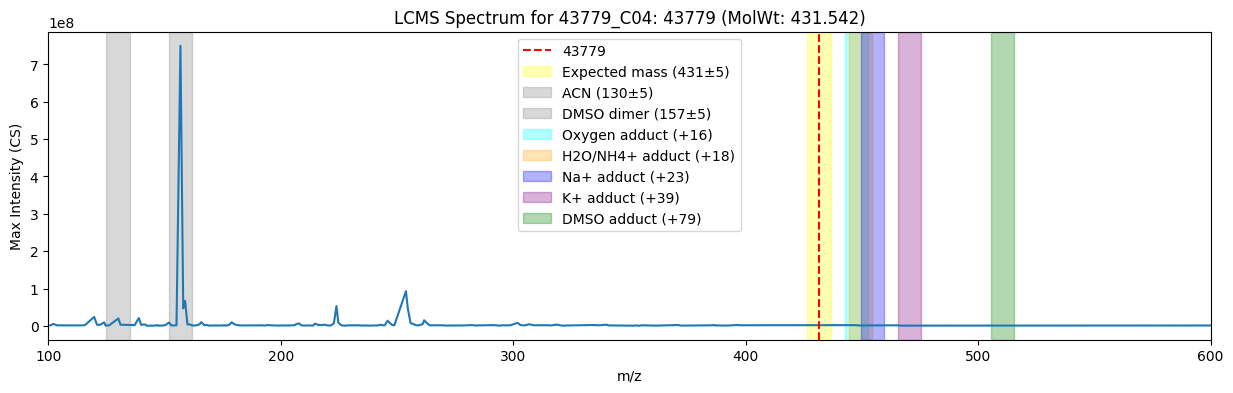

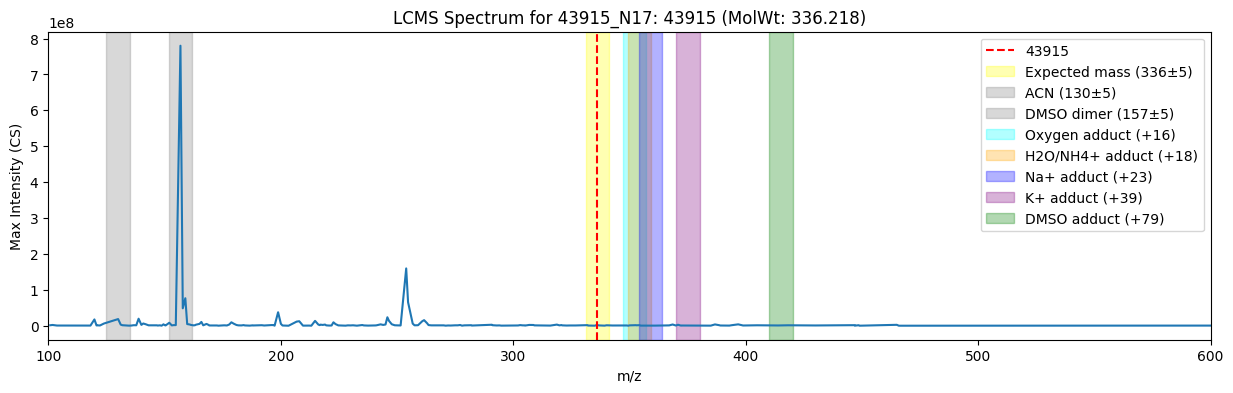

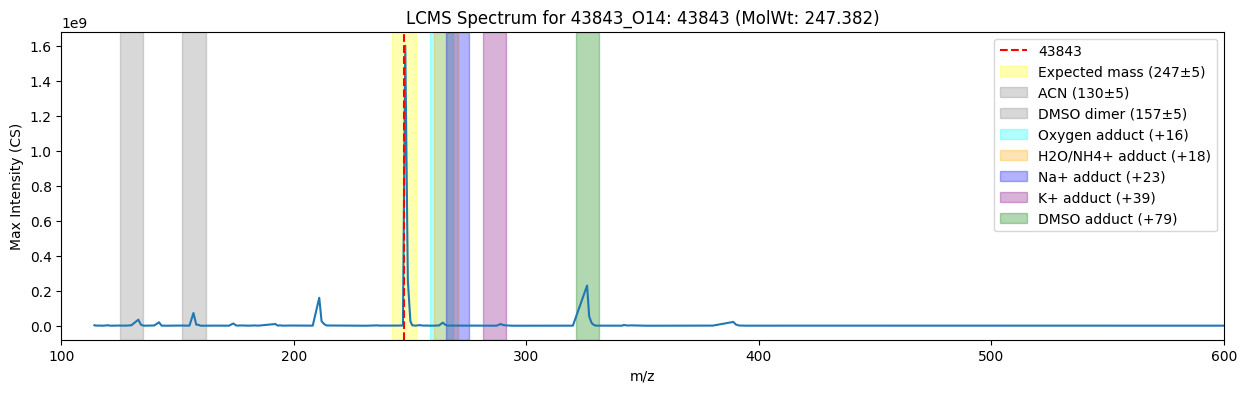

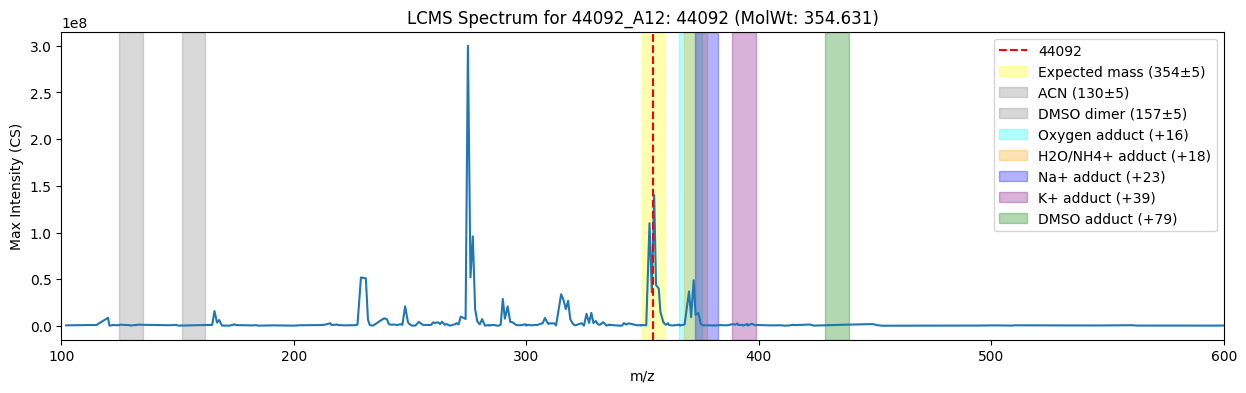

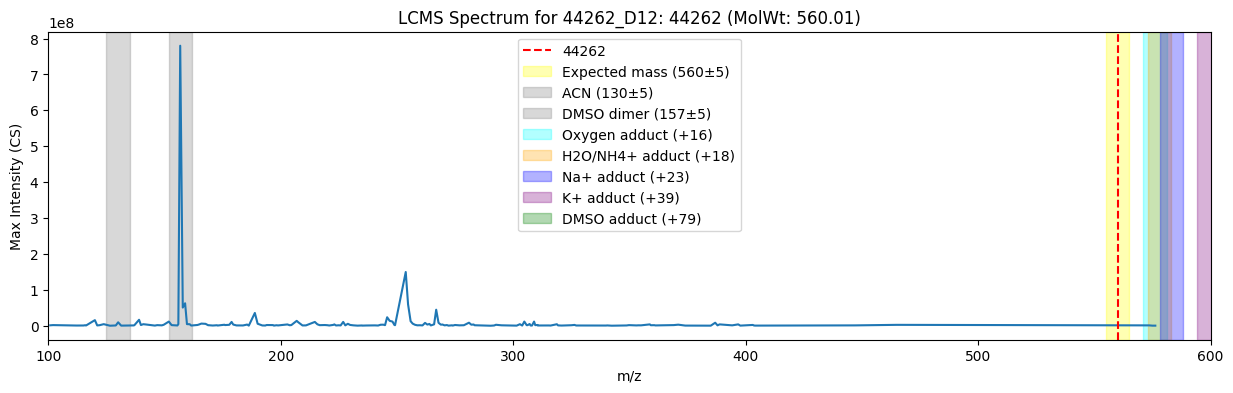

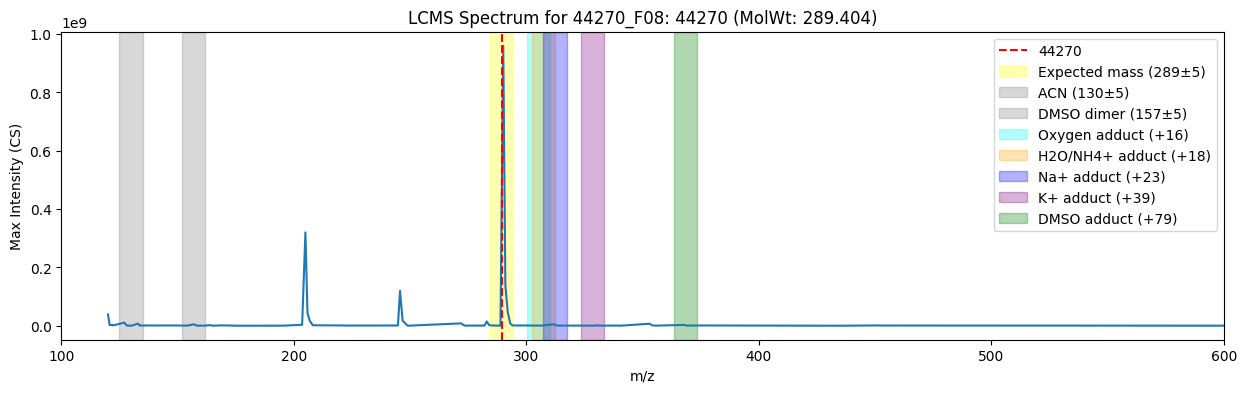

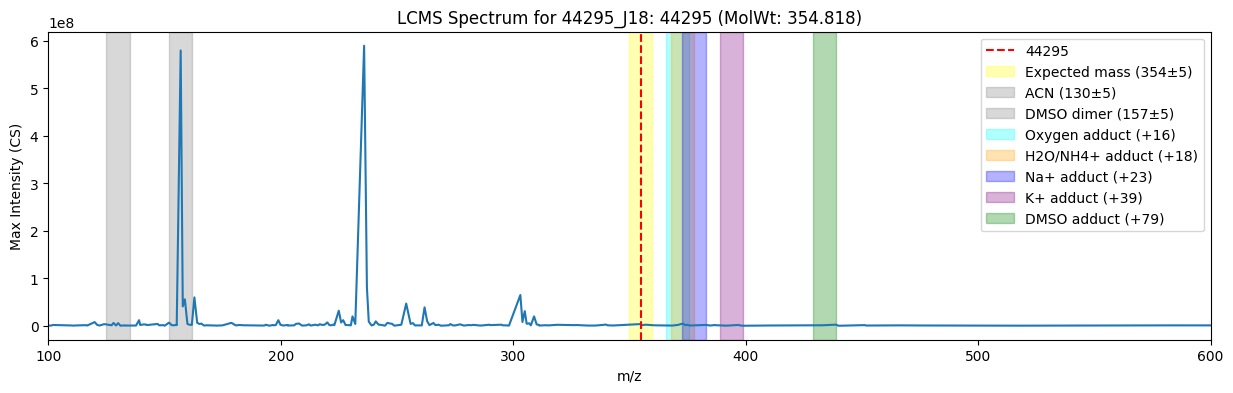

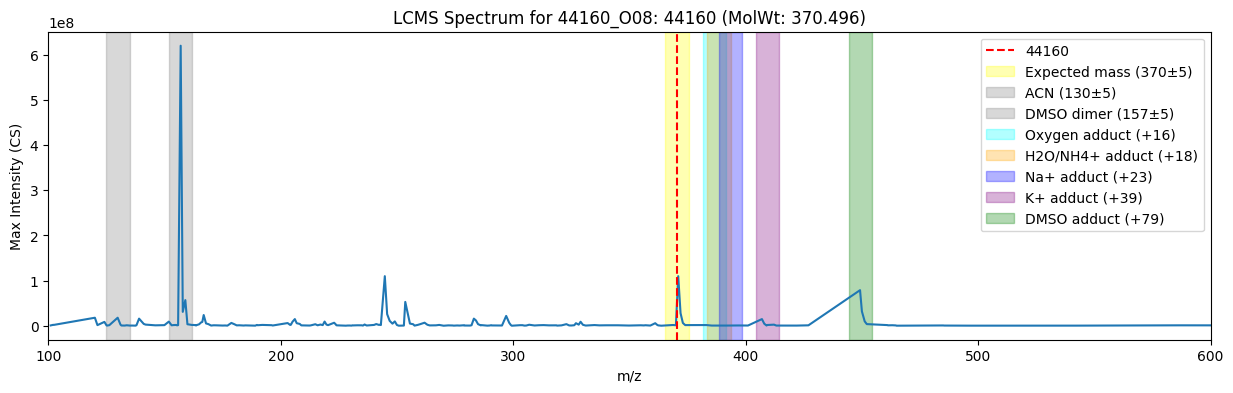

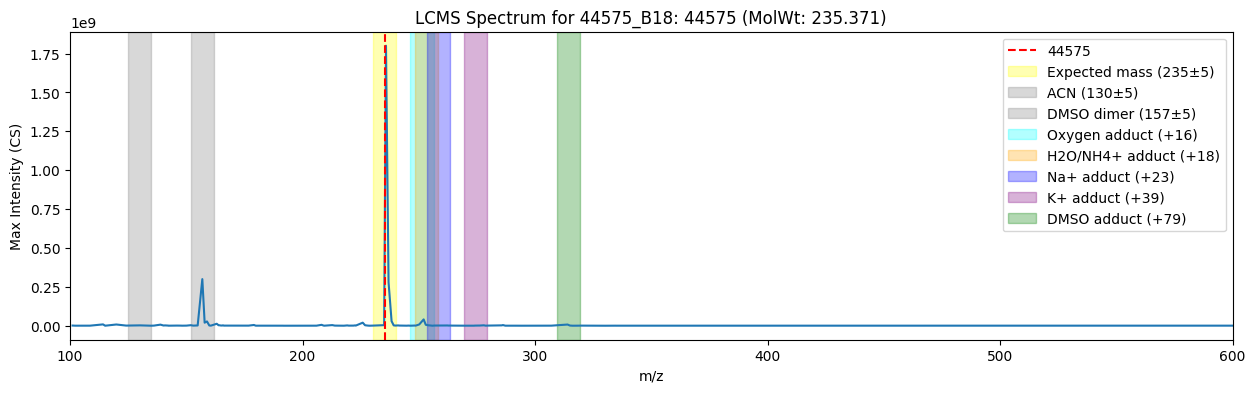

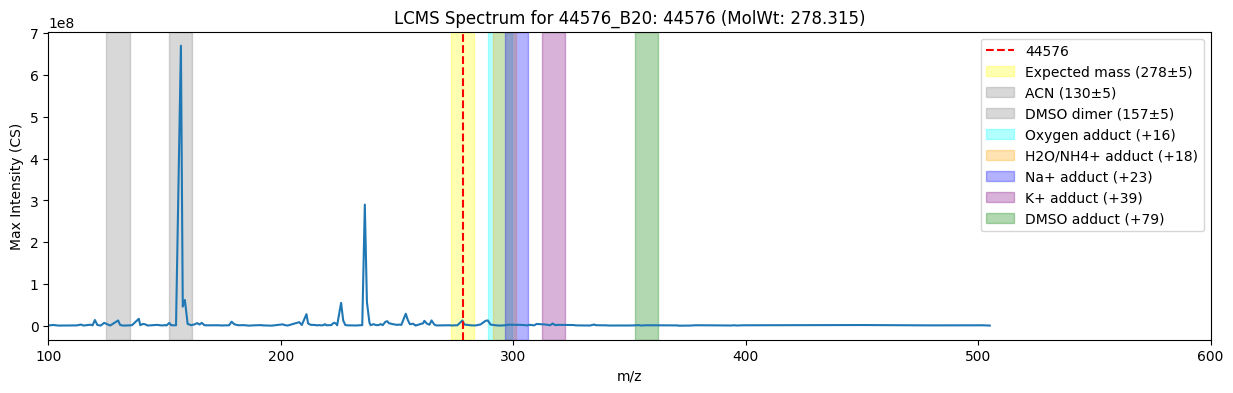

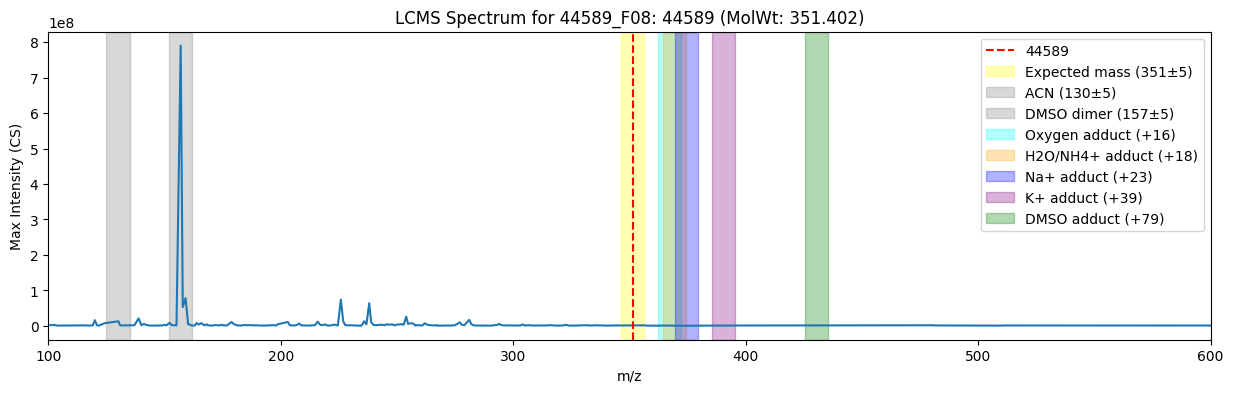

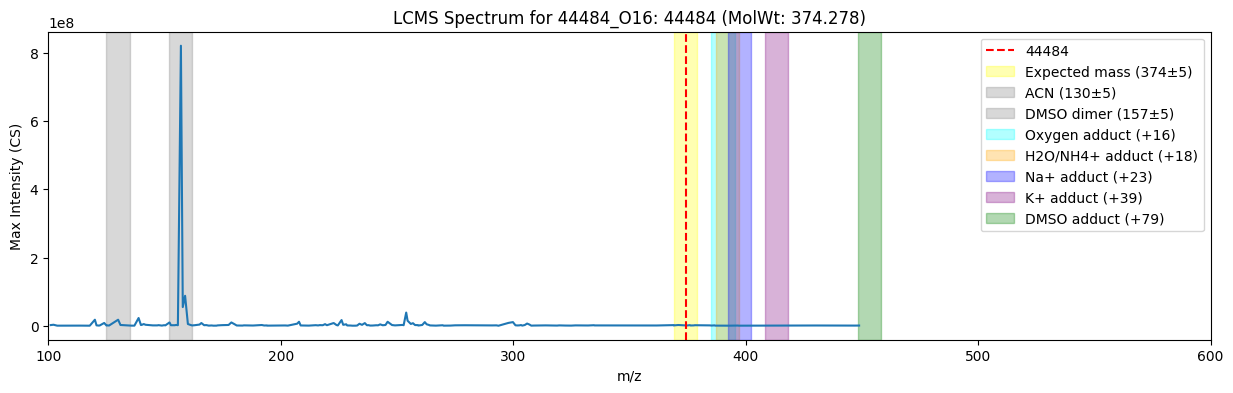

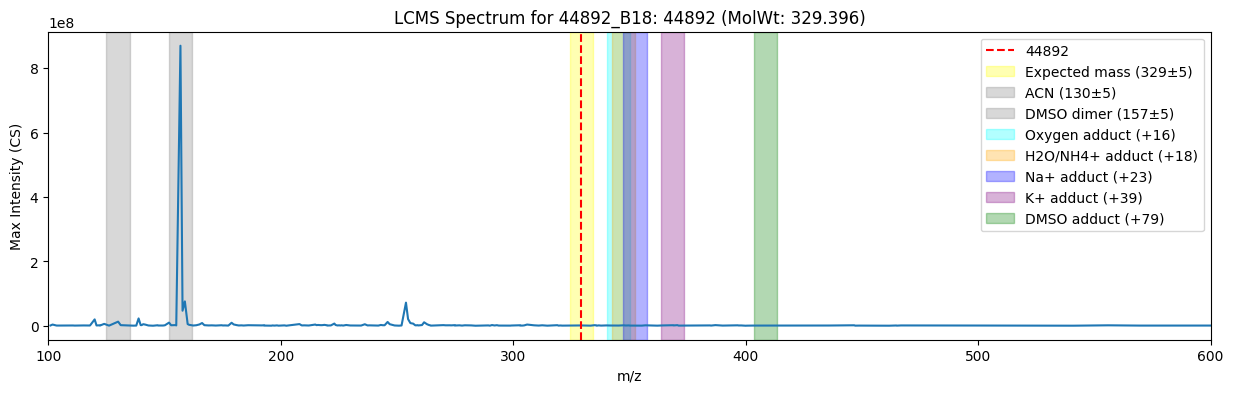

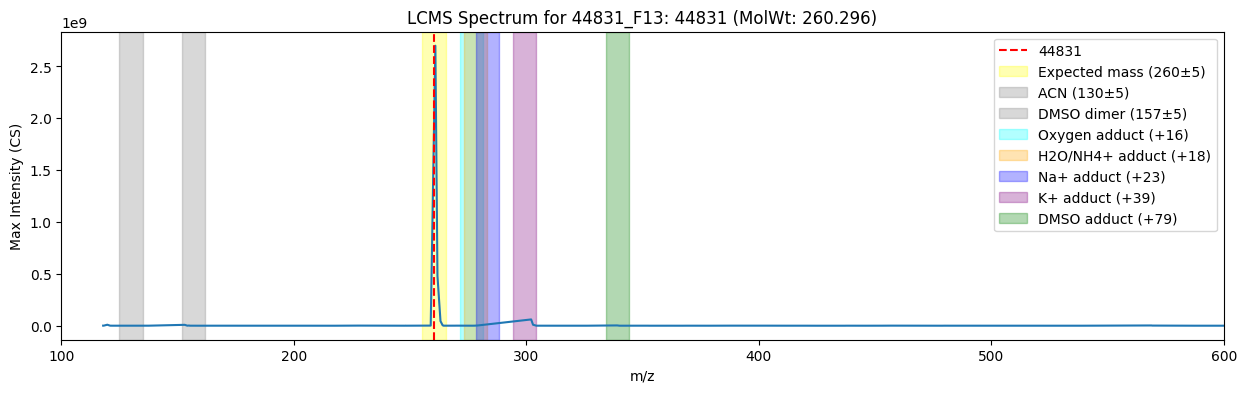

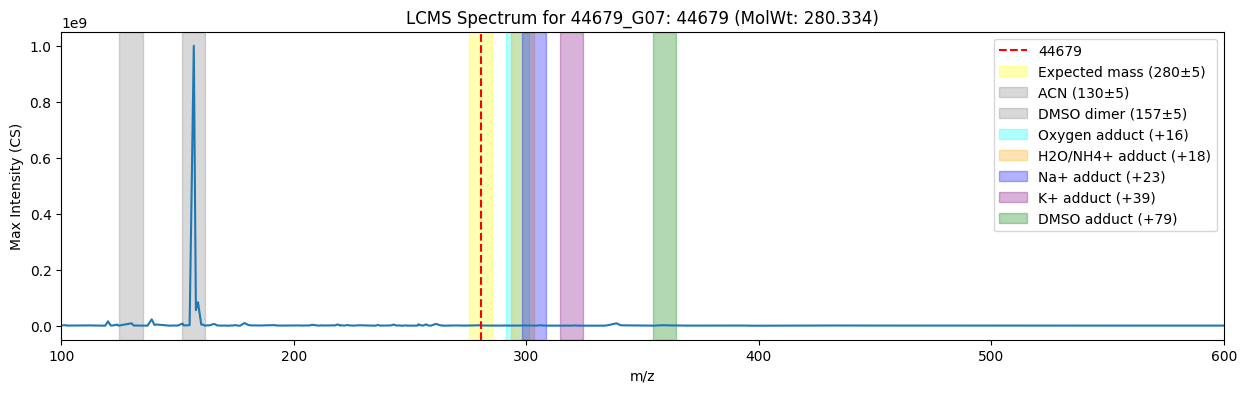

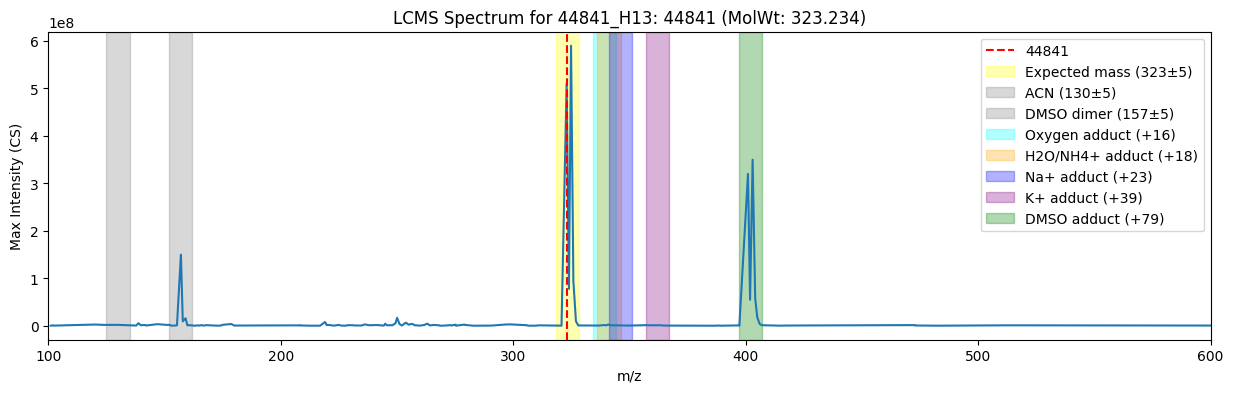

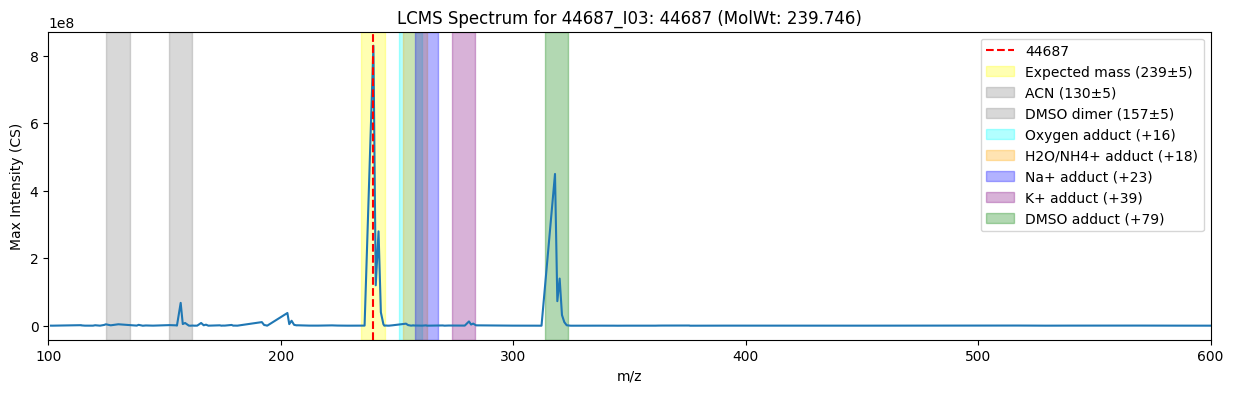

In [7]:
# low uv spectra only
for sample_id in low_peaks['sample_id'].tolist():
    data_df=al.read_lcms_results(sample_id, "20251117", kind="spectrum")
    al.plot_lcms_spectrum(sample_id, info_df, data_df, scan_range)#, save_dir="./mz_spectra")